# Tarification et détection d'anomalies sur les sinistres
## Approche hybride XGBoost, Autoencodeurs (DL) et Analyse Agentique (LLM)

Projet - IA & Assurance (ML, Deep Learning & IA Generative) - 2025-2026


## 1. Introduction et contexte métier

**Business case.** Ce projet vise à améliorer la tarification et la surveillance qualité des sinistres accidents du travail (workers compensation) a partir du jeu de données public Kaggle *Actuarial Loss Estimation* (54 000 polices). L'objectif est double :

1. **Predire** le coût ultime d'un sinistre (`UltimateIncurredClaimCost`) le plus tôt possible dans son cycle de vie, a partir des caractéristiques de la police, de l'assure et de la description libre du sinistre.
2. **Detecter automatiquement** les sinistres atypiques (potentielle fraude, erreur de saisie, sinistre complexe sous-provisionne) afin d'alerter les gestionnaires.

**Valeur ajoutée pour l'assureur** : une tarification plus fine réduit l'anti-sélection, une détection précoce des sinistres atypiques améliore le provisionnement (IBNER) et diminue la charge de sinistres non maîtrisée.

**Approche hybride retenue** (en réponse aux limites identifiées sur une première version du projet, notamment l'absence d'hyperparamétrage documente) :

| Flux | Technique | Role |
|---|---|---|
| 1. ML supervisé | XGBoost + recherche d'hyperparamètres (Optuna) | Modele de référence pour la prédiction du coût ultime |
| 2. Deep Learning non supervisé | Autoencodeur (Dense 64-32-16-32-64) | Detection d'anomalies sur les variables tabulaires, score réinjecté en feature |
| 3. NLP / IA générative | SentenceTransformer (embeddings) + agent de scoring de gravité | Exploitation de `ClaimDescription`, feature de gravité ordinale |

Chaque choix est justifie et une **analyse de sensibilité** (Etape 4) compare le modèle XGBoost seul aux versions enrichies par l'autoencodeur et par le flux NLP, afin de démontrer mathématiquement la valeur ajoutée de chaque brique.

**Plan du notebook** (aligne sur le plan de rapport attendu) :
- Etape 1 : Donnees et qualité
- Etape 2 : Analyse exploratoire (EDA)
- Etape 3 : Modelisation (3 flux + enrichissement)
- Etape 4 : Evaluation et sensibilités
- Etape 5 : Limites et perspectives

## 2. Framework technique

Librairies utilisées : `pandas`, `numpy`, `scikit-learn`, `xgboost`, `optuna` (recherche d'hyperparamètres bayesienne), `tensorflow`/`keras` (autoencodeur), `sentence-transformers` (embeddings texte), `matplotlib`/`seaborn` (visualisation).

Si une librairie manque dans votre environnement, decommentez la cellule d'installation ci-dessous.

In [ ]:
# !pip install pandas numpy scikit-learn xgboost lightgbm optuna tensorflow sentence-transformers matplotlib seaborn missingno wordcloud nltk shap statsmodels hdbscan

import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, KFold, RepeatedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.ensemble import IsolationForest
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_squared_error, mean_absolute_error, silhouette_score, cohen_kappa_score

import xgboost as xgb
import lightgbm as lgb
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import shap
from statsmodels.stats.outliers_influence import variance_inflation_factor
import hdbscan
from scipy import stats as sp_stats

pd.set_option('display.max_columns', 200)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
# keras.utils.set_random_seed couvre Python random, numpy et le backend TensorFlow en un
# seul appel, mais cela ne suffit pas à lui seul : testé empiriquement, deux exécutions
# distinctes du notebook donnaient encore des résultats d'autoencodeur différents (le
# threshold d'anomalie et les coûts par groupe de la Section 4.5 changeaient à chaque run).
# tf.config.experimental.enable_op_determinism() force en plus des opérations TensorFlow
# déterministes au niveau des noyaux de calcul (utile pour un autoencodeur de cette taille,
# le coût en temps de calcul est negligeable) : vérifié empiriquement, les deux ensemble
# rendent l'autoencodeur bit-à-bit identique d'une exécution à l'autre.
keras.utils.set_random_seed(RANDOM_STATE)
tf.config.experimental.enable_op_determinism()

## 3. Etape 1 - Acquisition des données

Source : [Kaggle - Actuarial Loss Estimation](https://www.kaggle.com/competitions/actuarial-loss-estimation/data). Le fichier `train.csv` (54 000 polices) doit être place dans `../data/raw/train.csv` (chemin relatif au notebook).

Aucun jeu de données n'etant fourni par l'enseignant, le téléchargement manuel depuis Kaggle (compte requis) constitue en soi une étape d'autonomie évaluée.

In [2]:
def load_data(path: str, filename: str, **kwargs) -> pd.DataFrame:
    """Load a csv file into a dataframe, raising a clear error if missing."""
    full_path = os.path.join(path, filename)
    if not os.path.exists(full_path):
        raise FileNotFoundError(
            'Dataset not found at ' + full_path +
            '. Download train.csv from the Kaggle actuarial-loss-estimation competition and place it there.'
        )
    return pd.read_csv(full_path, **kwargs)


DATA_PATH = os.path.join('..', 'data', 'raw')
FILENAME = 'train.csv'

claim_df = load_data(DATA_PATH, FILENAME)
print('shape:', claim_df.shape)
claim_df.head()

shape: (54000, 15)


,ClaimNumber,DateTimeOfAccident,DateReported,Age,Gender,MaritalStatus,DependentChildren,DependentsOther,WeeklyWages,PartTimeFullTime,HoursWorkedPerWeek,DaysWorkedPerWeek,ClaimDescription,InitialIncurredCalimsCost,UltimateIncurredClaimCost
0,WC8285054,2002-04-09T07:00:00Z,2002-07-05T00:00:00Z,48,M,M,0,0,500.00,F,38.0,5,LIFTING TYRE INJURY TO RIGHT ARM AND WRIST INJURY,1500,4748.203388
1,WC6982224,1999-01-07T11:00:00Z,1999-01-20T00:00:00Z,43,F,M,0,0,509.34,F,37.5,5,STEPPED AROUND CRATES AND TRUCK TRAY FRACTURE ...,5500,6326.285819
2,WC5481426,1996-03-25T00:00:00Z,1996-04-14T00:00:00Z,30,M,U,0,0,709.10,F,38.0,5,CUT ON SHARP EDGE CUT LEFT THUMB,1700,2293.949087
3,WC9775968,2005-06-22T13:00:00Z,2005-07-22T00:00:00Z,41,M,S,0,0,555.46,F,38.0,5,DIGGING LOWER BACK LOWER BACK STRAIN,15000,17786.487170
4,WC2634037,1990-08-29T08:00:00Z,1990-09-27T00:00:00Z,36,M,M,0,0,377.10,F,38.0,5,REACHING ABOVE SHOULDER LEVEL ACUTE MUSCLE STR...,2800,4014.002925


### 3.1 Controle qualité

On verifie la structure, les types, les valeurs manquantes et les doublons avant toute transformation.

In [3]:
claim_df.info()
print()
print('Doublons:', claim_df.duplicated().sum())
print()
missing = claim_df.isnull().sum()
missing_pct = (missing / len(claim_df) * 100).round(3)
missing_report = pd.DataFrame({'n_missing': missing, 'pct_missing': missing_pct})
missing_report[missing_report['n_missing'] > 0]

<class 'pandas.DataFrame'>
RangeIndex: 54000 entries, 0 to 53999
Data columns (total 15 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   ClaimNumber                54000 non-null  str    
 1   DateTimeOfAccident         54000 non-null  str    
 2   DateReported               54000 non-null  str    
 3   Age                        54000 non-null  int64  
 4   Gender                     54000 non-null  str    
 5   MaritalStatus              53971 non-null  str    
 6   DependentChildren          54000 non-null  int64  
 7   DependentsOther            54000 non-null  int64  
 8   WeeklyWages                54000 non-null  float64
 9   PartTimeFullTime           54000 non-null  str    
 10  HoursWorkedPerWeek         54000 non-null  float64
 11  DaysWorkedPerWeek          54000 non-null  int64  
 12  ClaimDescription           54000 non-null  str    
 13  InitialIncurredCalimsCost  54000 non-null  int64  
 14  U

,n_missing,pct_missing
MaritalStatus,29,0.054


### 3.2 Nettoyage et typage

**Justification du choix de traitement des valeurs manquantes** : `MaritalStatus` présente moins de 0.05% de valeurs manquantes (29 lignes sur 54 000). Une imputation par le mode (choix de la version précédente de ce notebook) est **rejetée ici** : en assurance, une donnée manquante n'est presque jamais absente au hasard (MNAR - *Missing Not At Random*). Un champ non renseigne lors d'une déclaration de sinistre peut refléter une urgence extrême (blessure grave, la paperasse administrative passant au second plan) ou une déclaration incomplète/atypique. Forcer ces 29 lignes vers le statut marital majoritaire **detruirait ce signal potentiel** sans justification.

**Traitement retenu** : création d'une catégorie explicite `"Missing"`, traitée comme un niveau catégoriel à part entière (XGBoost et le one-hot encoding gèrent nativement les catégories isolées, y compris rares). La Section 2.3 vérifie statistiquement si ces 29 dossiers présentent un `UltimateIncurredClaimCost` différent du reste du portefeuille, plutôt que de supposer que la question ne se pose pas.

In [4]:
SCHEMA = {
    'target': 'UltimateIncurredClaimCost',
    'num_features': ['Age', 'WeeklyWages', 'HoursWorkedPerWeek', 'DaysWorkedPerWeek', 'InitialIncurredCalimsCost'],
    'date_features': ['DateTimeOfAccident', 'DateReported'],
    'cat_features': ['Gender', 'MaritalStatus', 'DependentChildren', 'DependentsOther', 'PartTimeFullTime'],
    'id_feature': 'ClaimNumber',
    'text_feature': 'ClaimDescription',
}


def preprocess_data(df: pd.DataFrame, schema: dict) -> pd.DataFrame:
    """Enforce the target dtype schema. Missing MaritalStatus is kept as its own
    explicit category rather than imputed (see justification in the markdown above):
    an absent declarative field is not necessarily Missing At Random in an insurance
    context, and forcing it to the modal category would destroy that signal.
    """
    df = df.copy()

    df['MaritalStatus'] = df['MaritalStatus'].fillna('Missing')

    for col in schema['cat_features'] + [schema['id_feature'], schema['text_feature']]:
        df[col] = df[col].astype('str')

    for col in schema['date_features']:
        df[col] = pd.to_datetime(df[col])

    return df


claim_df = preprocess_data(claim_df, SCHEMA)
print('Valeurs manquantes restantes:', claim_df.isnull().sum().sum())
claim_df.dtypes


Valeurs manquantes restantes: 0


ClaimNumber                                  str
DateTimeOfAccident           datetime64[us, UTC]
DateReported                 datetime64[us, UTC]
Age                                        int64
Gender                                       str
MaritalStatus                                str
DependentChildren                            str
DependentsOther                              str
WeeklyWages                              float64
PartTimeFullTime                             str
HoursWorkedPerWeek                       float64
DaysWorkedPerWeek                          int64
ClaimDescription                             str
InitialIncurredCalimsCost                  int64
UltimateIncurredClaimCost                float64
dtype: object

**Verification empirique (plutôt que suppositive)** : les 29 sinistres a `MaritalStatus` manquant ont-ils un coût différent du reste du portefeuille ? La cible etant fortement asymétrique (skewness 37.6), un test paramétrique (t-test) serait invalide ; on utilise le test non paramétrique de **Mann-Whitney U**, qui compare les distributions par les rangs sans hypothèse de normalité.

In [5]:
from scipy.stats import mannwhitneyu

is_missing_marital = claim_df['MaritalStatus'] == 'Missing'
cost_missing = claim_df.loc[is_missing_marital, SCHEMA['target']]
cost_known = claim_df.loc[~is_missing_marital, SCHEMA['target']]

print('MaritalStatus manquant : n =', len(cost_missing))
print('  coût moyen  :', round(cost_missing.mean(), 2), ' coût median :', round(cost_missing.median(), 2))
print('MaritalStatus renseigne : n =', len(cost_known))
print('  coût moyen  :', round(cost_known.mean(), 2), ' coût median :', round(cost_known.median(), 2))

u_stat, p_value = mannwhitneyu(cost_missing, cost_known, alternative='two-sided')
print('\nTest de Mann-Whitney U : statistique =', round(u_stat, 1), ' p-value =', round(p_value, 4))
if p_value < 0.05:
    print('-> Difference statistiquement significative au seuil de 5% : le signal MNAR est corrobore,')
    print('   la catégorie "Missing" doit être conservée comme feature informative.')
else:
    print('-> Pas de difference statistiquement significative au seuil de 5% sur cet échantillon (n=29,')
    print('   puissance statistique limitée). La catégorie "Missing" est néanmoins conservée par principe')
    print('   de precaution méthodologique (cf. Section 3.2) plutôt que d\'imposer le mode.')

MaritalStatus manquant : n = 29
  coût moyen  : 5325.9  coût median : 1481.96
MaritalStatus renseigne : n = 53971
  coût moyen  : 11006.42  coût median : 3371.69

Test de Mann-Whitney U : statistique = 635481.0  p-value = 0.0796
-> Pas de difference statistiquement significative au seuil de 5% sur cet échantillon (n=29,
   puissance statistique limitée). La catégorie "Missing" est néanmoins conservée par principe
   de precaution méthodologique (cf. Section 3.2) plutôt que d'imposer le mode.


### 3.3 Traitement des valeurs aberrantes ("Garbage In, Garbage Out")

XGBoost est réputée robuste aux outliers, mais cette robustesse concerne la variance du modèle, pas la validité métier des données. Laisser passer des valeurs physiquement impossibles (ex. `HoursWorkedPerWeek` > 168h, plus d'heures que n'en contient une semaine) revient à apprendre sur du bruit plutôt que sur un signal, et peut biaiser silencieusement les statistiques descriptives, les corrélations et l'autoencodeur (qui lui n'a aucune robustesse native aux outliers puisqu'il minimise une MSE).

**Traitement en deux temps, avec traçabilité complète :**

1. **Regles métier (implausibilite physique)** : `HoursWorkedPerWeek` ne peut excéder 168h/semaine (24h x 7j) ; on retient un plafond réaliste de 98h (14h/jour x 7j, déjà très généreux) au-dela duquel la valeur est considérée comme une erreur de saisie. `DaysWorkedPerWeek` ne peut excéder 7. Les valeurs hors bornes sont traitées comme manquantes puis imputées par la médiane.
2. **Winsorization statistique (1er/99e percentile)** sur `WeeklyWages`, `HoursWorkedPerWeek` et `DaysWorkedPerWeek` après l'étape 1, pour atténuer l'influence des valeurs extrêmes restantes mais plausibles.

Une **copie brute est conservée** (`claim_df_raw_numeric`) pour quantifier plus loin (Section 9) l'impact réel de ce traitement sur la performance du modèle - plutôt que de l'assumer.

In [ ]:
NUM_TREATED_COLS = ['WeeklyWages', 'HoursWorkedPerWeek', 'DaysWorkedPerWeek']

# Copie brute conservée pour l'ablation "raw vs cleaned" de la Section 4.4.
claim_df_raw_numeric = claim_df[NUM_TREATED_COLS].copy()

PLAUSIBLE_MAX = {'HoursWorkedPerWeek': 98, 'DaysWorkedPerWeek': 7}


def apply_business_rules(df: pd.DataFrame, plausible_max: dict) -> pd.DataFrame:
    """Treat physically implausible values as missing, then impute by the median."""
    df = df.copy()
    for col, cap in plausible_max.items():
        n_invalid = (df[col] > cap).sum()
        if n_invalid > 0:
            df.loc[df[col] > cap, col] = np.nan
            df[col] = df[col].fillna(df[col].median())
        print(f'{col}: {n_invalid} valeurs implausibles (> {cap}) corrigees par la médiane')
    return df


def winsorize(df: pd.DataFrame, cols: list, lower_pct: float = 1, upper_pct: float = 99) -> pd.DataFrame:
    """Cap remaining statistical extrêmes at the given percentiles."""
    df = df.copy()
    for col in cols:
        lo, hi = np.percentile(df[col], [lower_pct, upper_pct])
        df[col] = df[col].clip(lower=lo, upper=hi)
    return df


print('--- Avant traitement ---')
print(claim_df[NUM_TREATED_COLS].describe().loc[['mean', 'std', 'max']])

claim_df = apply_business_rules(claim_df, PLAUSIBLE_MAX)
claim_df = winsorize(claim_df, NUM_TREATED_COLS)

print('\n--- Apres traitement ---')
print(claim_df[NUM_TREATED_COLS].describe().loc[['mean', 'std', 'max']])

--- Avant traitement ---
      WeeklyWages  HoursWorkedPerWeek  DaysWorkedPerWeek
mean   416.364807           37.735084           4.905759
std    248.638669           12.568704           0.552129
max   7497.000000          640.000000           7.000000
HoursWorkedPerWeek: 38 valeurs implausibles (> 98) corrigees par la médiane
DaysWorkedPerWeek: 0 valeurs implausibles (> 7) corrigees par la médiane

--- Apres traitement ---
      WeeklyWages  HoursWorkedPerWeek  DaysWorkedPerWeek
mean   411.877173           37.413432           4.903167
std    216.412231            6.363996           0.512527
max   1237.520000           60.000000           6.000000


## 4. Etape 2 - Analyse exploratoire (EDA)

### 4.1 Variable cible : `UltimateIncurredClaimCost`

On s'attend à une distribution fortement asymétrique (queue lourde à droite), typique des coûts de sinistres.

count    5.400000e+04
mean     1.100337e+04
std      3.339099e+04
min      1.218868e+02
25%      9.263384e+02
50%      3.371242e+03
75%      8.197249e+03
max      4.027136e+06
Name: UltimateIncurredClaimCost, dtype: float64
Skewness: 37.55


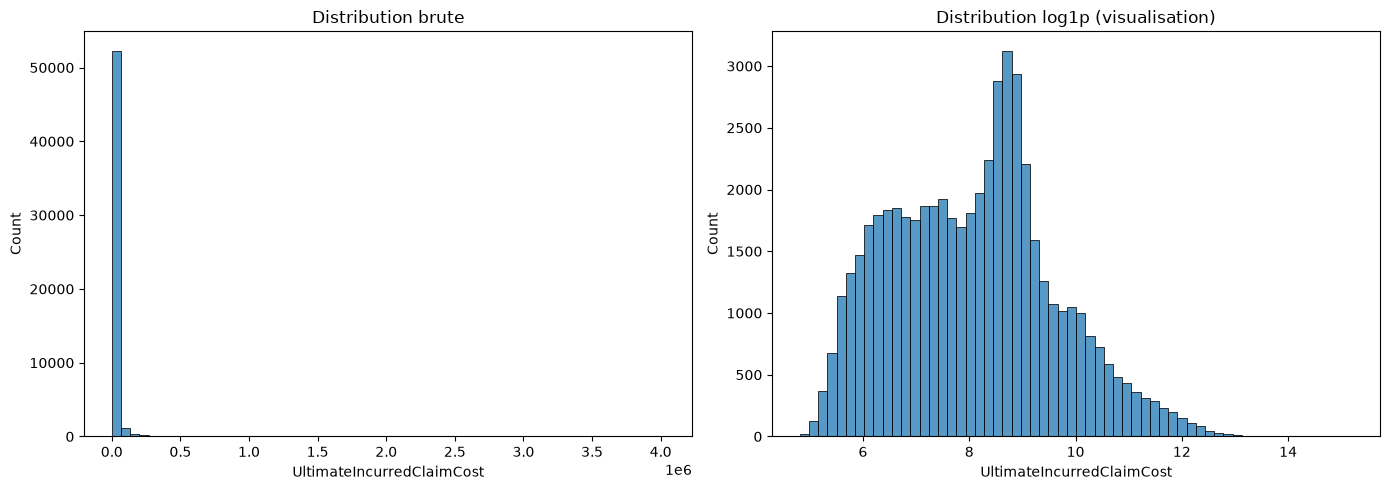

In [7]:
target = SCHEMA['target']
print(claim_df[target].describe())
print('Skewness:', claim_df[target].skew().round(2))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(claim_df[target], bins=60, ax=axes[0])
axes[0].set_title('Distribution brute')
sns.histplot(np.log1p(claim_df[target]), bins=60, ax=axes[1])
axes[1].set_title('Distribution log1p (visualisation)')
plt.tight_layout()
plt.show()

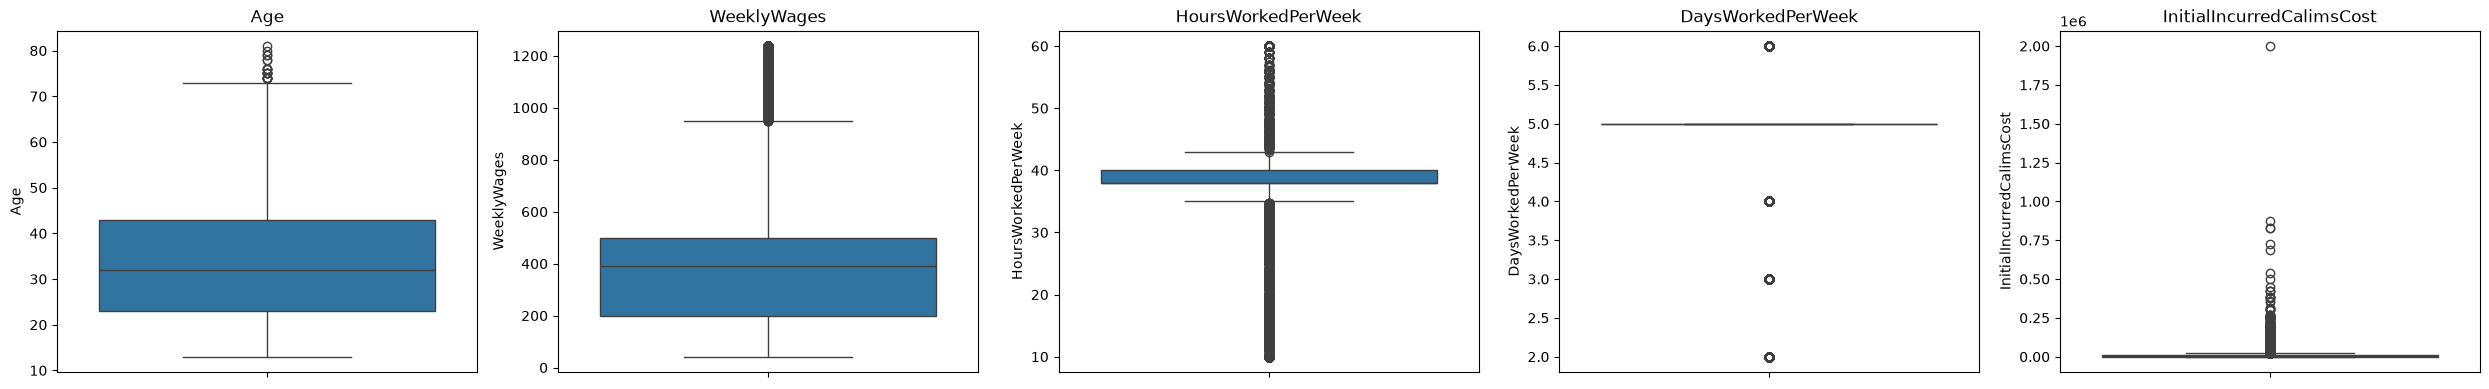

InitialIncurredCalimsCost    26.85
WeeklyWages                   1.15
Age                           0.54
HoursWorkedPerWeek           -1.65
DaysWorkedPerWeek            -3.63
dtype: float64

In [8]:
# 4.2 Variables numériques
num_features = SCHEMA['num_features']
fig, axes = plt.subplots(1, len(num_features), figsize=(5 * len(num_features), 4))
for ax, col in zip(axes, num_features):
    sns.boxplot(y=claim_df[col], ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

claim_df[num_features].describe()

# Skewness individuelle : utile ici pour justifier plus loin (Section 6.1ter/GLM) le
# log-transform d'appliquer à InitialIncurredCalimsCost avant de l utiliser dans un GLM.
claim_df[num_features].skew().round(2).sort_values(ascending=False)

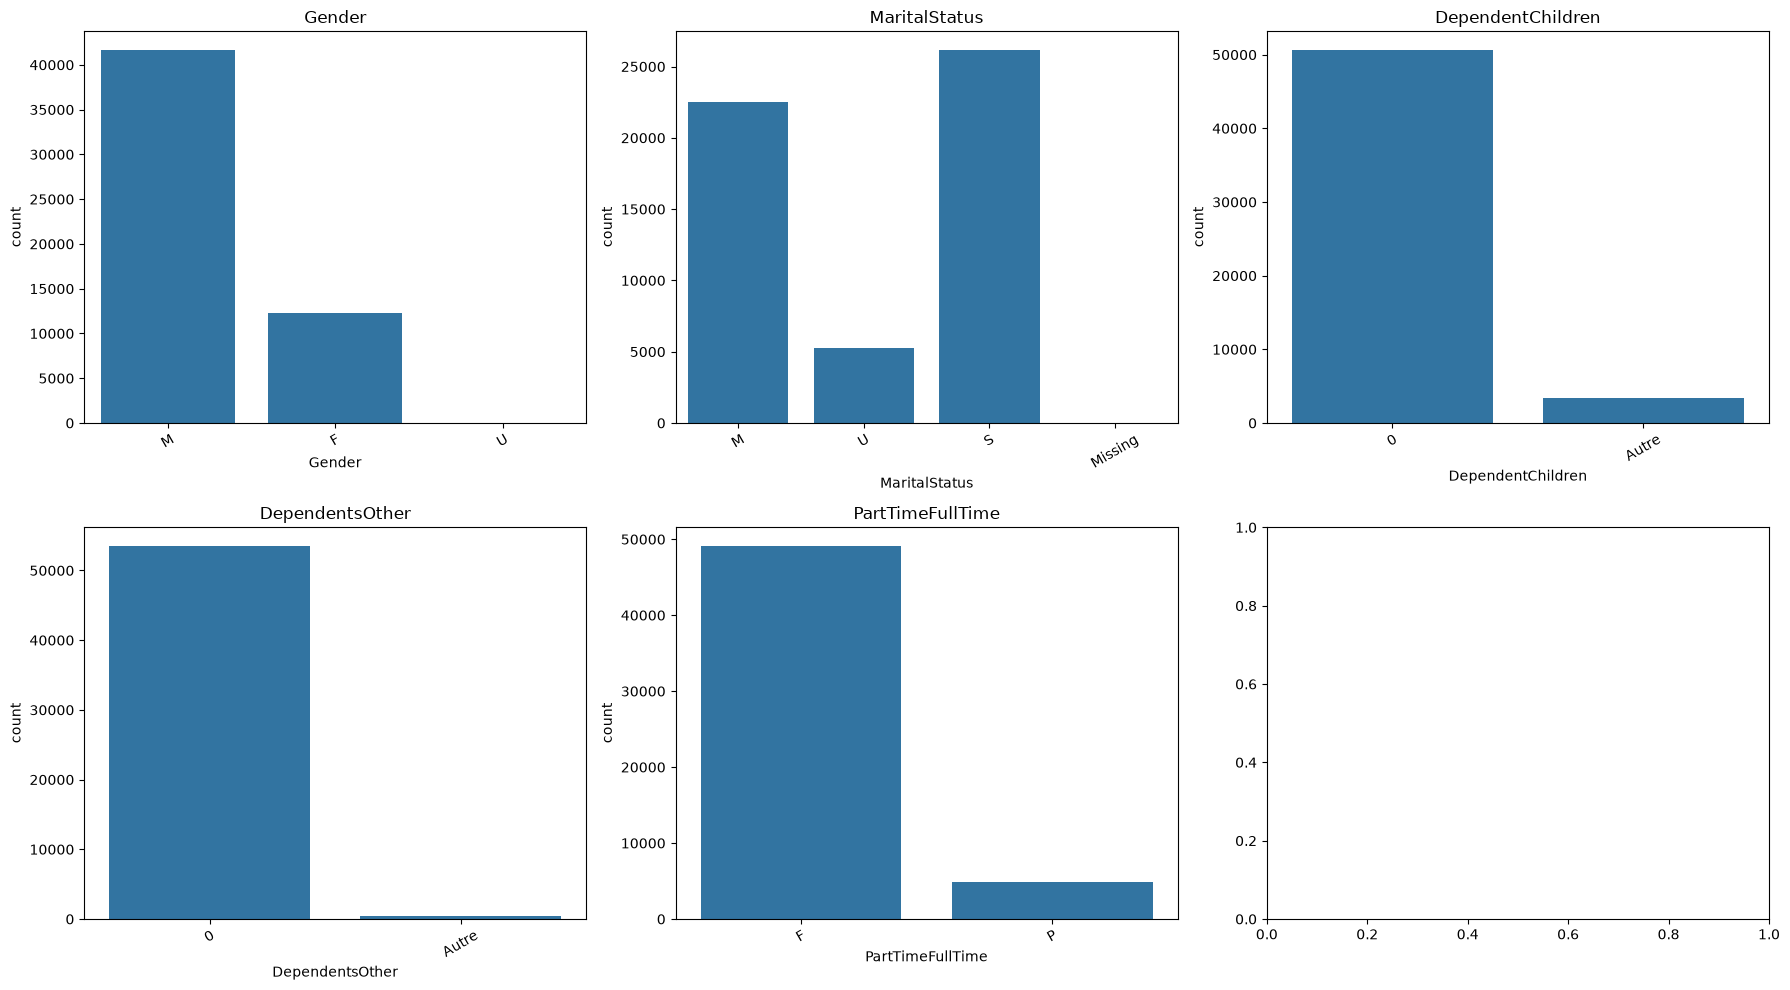

In [9]:
# 4.3 Variables catégorielles - regroupement des modalités rares (< 5%)

def merge_rare_categories(séries: pd.Series, min_pct: float = 5.0) -> pd.Series:
    freq = séries.value_counts(normalize=True) * 100
    rare = freq[freq < min_pct].index
    return séries.where(~séries.isin(rare), other='Autre')


cat_features = SCHEMA['cat_features']
for col in ['DependentChildren', 'DependentsOther']:
    claim_df[col] = merge_rare_categories(claim_df[col])

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for ax, col in zip(axes.ravel(), cat_features):
    sns.countplot(data=claim_df, x=col, ax=ax)
    ax.tick_params(axis='x', rotation=30)
    ax.set_title(col)
plt.tight_layout()
plt.show()

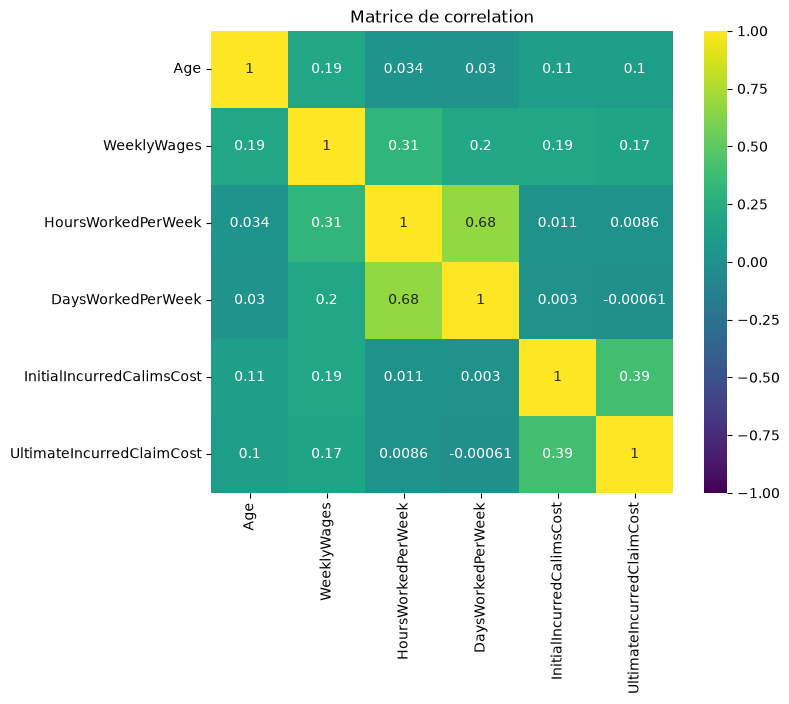

In [10]:
# 4.4 Correlations entre variables numériques et la cible
corr = claim_df[num_features + [target]].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='viridis', vmin=-1, vmax=1, square=True)
plt.title('Matrice de corrélation')
plt.show()

### 4.4bis Corrélations robustes (Spearman) et multicolinéarité (VIF)

La cible étant fortement asymétrique, le coefficient de **Pearson** (Section 4.4) sous-estime les relations non linéaires monotones. On complète par le coefficient de **Spearman** (rangs), plus robuste aux valeurs extrêmes et à la non-linéarité. On calcule également le **VIF** (Variance Inflation Factor) pour détecter une éventuelle multicolinéarité entre variables explicatives, qui fragiliserait l'interprétation de l'importance des features (Section 10).

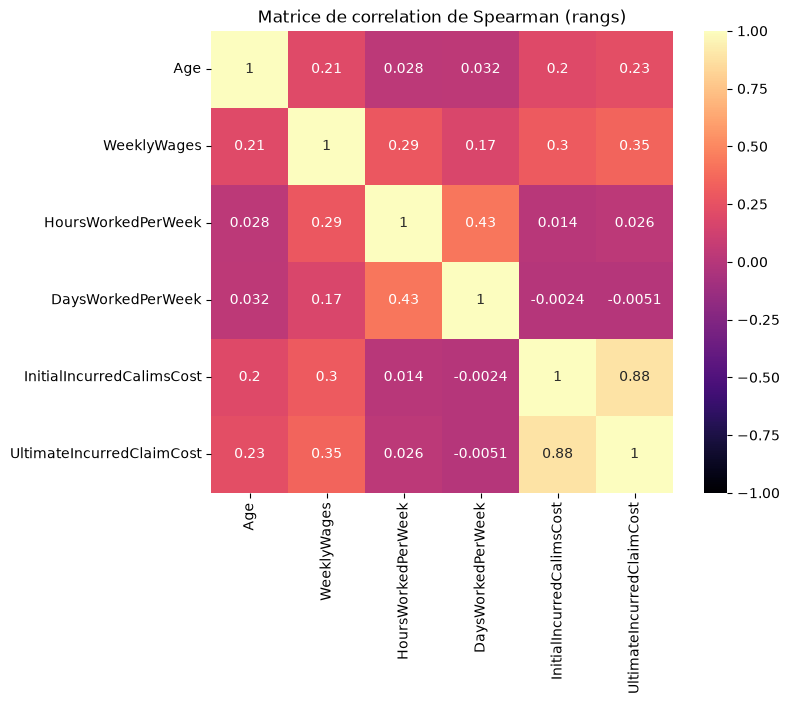

Ecart Pearson -> Spearman pour la cible :
InitialIncurredCalimsCost    0.488
WeeklyWages                  0.184
Age                          0.131
HoursWorkedPerWeek           0.017
UltimateIncurredClaimCost    0.000
DaysWorkedPerWeek           -0.004
Name: UltimateIncurredClaimCost, dtype: float64

Variance Inflation Factor (VIF < 5 = pas de colinéarité preoccupante) :
                     feature       VIF
2         HoursWorkedPerWeek  1.965791
3          DaysWorkedPerWeek  1.842581
1                WeeklyWages  1.189570
4  InitialIncurredCalimsCost  1.048930
0                        Age  1.045784


In [11]:
spearman_corr = claim_df[num_features + [target]].corr(method='spearman')
plt.figure(figsize=(8, 6))
sns.heatmap(spearman_corr, annot=True, cmap='magma', vmin=-1, vmax=1, square=True)
plt.title('Matrice de corrélation de Spearman (rangs)')
plt.show()

print('Ecart Pearson -> Spearman pour la cible :')
print((spearman_corr[target] - corr[target]).round(3).sort_values(ascending=False))

# VIF : nécessite une constante et l'absence de colinéarité parfaite
X_vif = claim_df[num_features].assign(const=1.0)
vif_data = pd.DataFrame({
    'feature': num_features,
    'VIF': [variance_inflation_factor(X_vif.values, i) for i in range(len(num_features))],
})
print('\nVariance Inflation Factor (VIF < 5 = pas de colinéarité preoccupante) :')
print(vif_data.sort_values('VIF', ascending=False))

### 4.4ter Information mutuelle et Predictive Power Score (relations non linéaires)

Pearson et Spearman restent des mesures de relation **monotone**. Pour capter des relations non linéaires plus générales (ex. en U, en seuil), on ajoute deux mesures supplémentaires, plus robustes à l'asymetrie extrême de la cible :

- **Information mutuelle** (`mutual_info_regression`) : mesure la réduction d'incertitude sur la cible apportée par chaque variable, sans hypothèse de forme fonctionnelle.
- **Predictive Power Score (PPS)** : score empirique (0 a 1) base sur la capacité d'un arbre de décision simple (une seule feature en entrée) a prédire la cible, comparé à une baseline naive (prédiction par la médiane). Contrairement à une corrélation, le PPS est asymétrique (X prédit Y ne veut pas dire Y prédit X) et capture nativement les non-linearites.

                  feature  mutual_info      pps
InitialIncurredCalimsCost     0.910888 0.220292
              WeeklyWages     0.123307 0.000000
                      Age     0.031331 0.000000
       HoursWorkedPerWeek     0.018725 0.000000
        DaysWorkedPerWeek     0.005395 0.000000


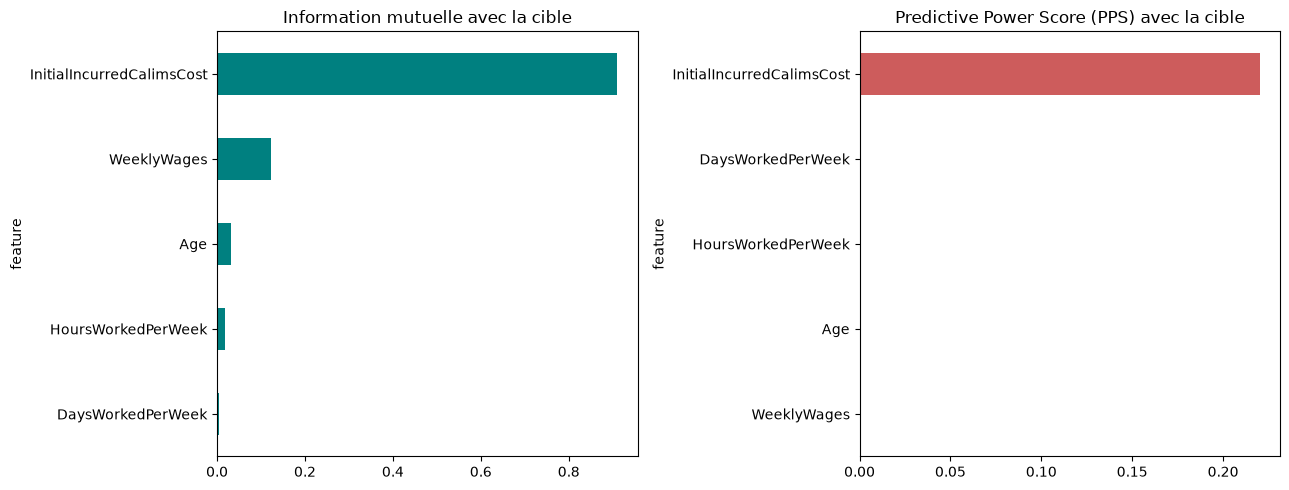

In [12]:
from sklearn.feature_selection import mutual_info_regression
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import KFold as _KFold
from sklearn.metrics import mean_absolute_error as _mae

X_num = claim_df[num_features].values
y_num = claim_df[target].values

mi_scores = mutual_info_regression(X_num, y_num, random_state=RANDOM_STATE)
mi_df = pd.DataFrame({'feature': num_features, 'mutual_info': mi_scores}).sort_values(
    'mutual_info', ascending=False)


def predictive_power_score(x: np.ndarray, y: np.ndarray, n_splits: int = 5) -> float:
    """Simplified single-feature PPS: out-of-fold MAE of a shallow tree vs a naive
    median baseline, rescaled to [0, 1] (0 = no better than naive, 1 = perfect)."""
    kf = _KFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
    x = x.reshape(-1, 1)
    tree_errors, naive_errors = [], []
    for train_idx, test_idx in kf.split(x):
        tree = DecisionTreeRegressor(max_depth=4, random_state=RANDOM_STATE)
        tree.fit(x[train_idx], y[train_idx])
        tree_errors.append(_mae(y[test_idx], tree.predict(x[test_idx])))
        naive_pred = np.full(len(test_idx), np.median(y[train_idx]))
        naive_errors.append(_mae(y[test_idx], naive_pred))
    tree_mae, naive_mae = np.mean(tree_errors), np.mean(naive_errors)
    return max(0.0, 1 - tree_mae / naive_mae)


pps_scores = [predictive_power_score(claim_df[col].values, y_num) for col in num_features]
mi_df['pps'] = [pps_scores[num_features.index(f)] for f in mi_df['feature']]

print(mi_df.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
mi_df.set_index('feature')['mutual_info'].sort_values().plot(kind='barh', ax=axes[0], color='teal')
axes[0].set_title('Information mutuelle avec la cible')
mi_df.set_index('feature')['pps'].sort_values().plot(kind='barh', ax=axes[1], color='indianred')
axes[1].set_title('Predictive Power Score (PPS) avec la cible')
plt.tight_layout()
plt.show()

### 4.4quater Analyse bivariée des variables catégorielles (fréquence et sévérité)

Lister des variables catégorielles sans étudier leur lien avec la cible est insuffisant pour justifier des choix de tarification. Pour chaque variable (`Gender`, `MaritalStatus`, `PartTimeFullTime`, `DependentChildren`, `DependentsOther`), on croise **fréquence** (répartition des sinistres) et **sévérité** (coût moyen/median par niveau), et on teste si les distributions de coût différent significativement entre niveaux via le test de **Kruskal-Wallis** (équivalent non paramétrique de l'ANOVA, adapte à une cible non normale).

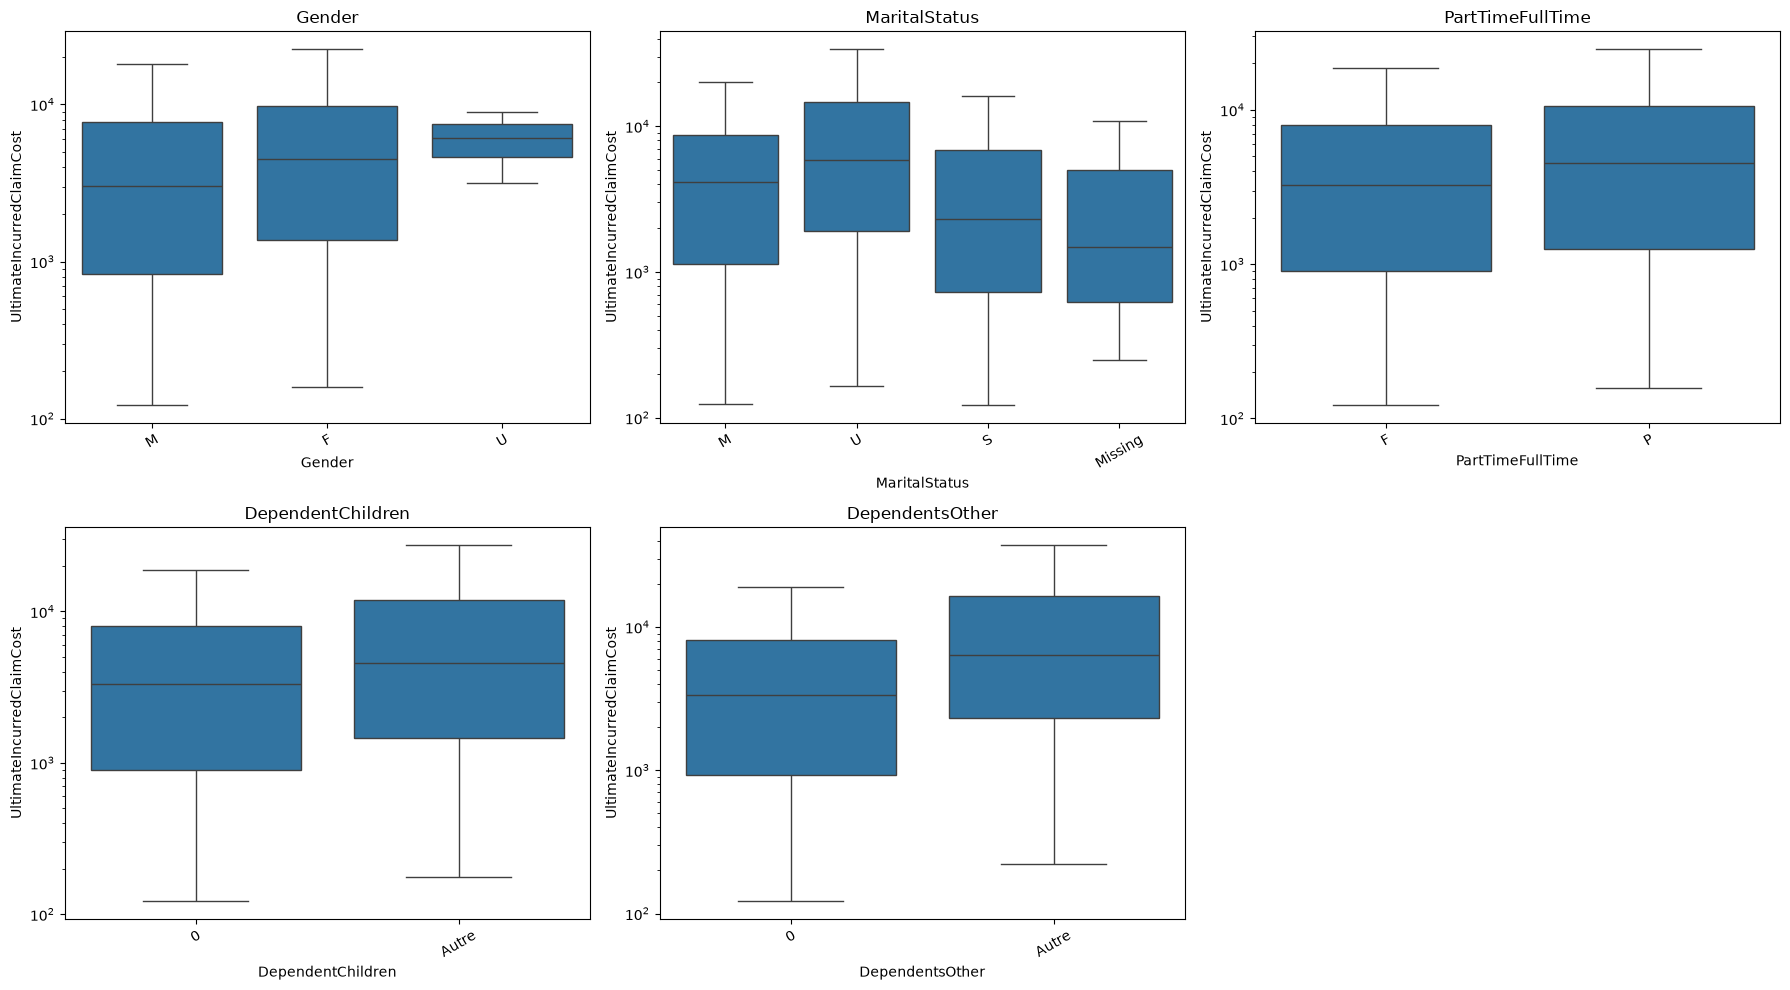

          feature   kruskal_H       p_value  significatif_5pct
           Gender  471.183719 4.827868e-103               True
    MaritalStatus 1501.625328  0.000000e+00               True
 PartTimeFullTime  163.307016  2.143630e-37               True
DependentChildren  176.420817  2.930514e-40               True
  DependentsOther  102.497180  4.319823e-24               True

Frequence et sévérité (moyenne, médiane) par niveau :

--- Gender ---
         freq  mean_cost  median_cost  freq_pct
Gender                                         
F       12338    12877.6       4487.1      22.8
M       41660    10448.5       3043.5      77.2
U           2     6086.3       6086.3       0.0

--- MaritalStatus ---
                freq  mean_cost  median_cost  freq_pct
MaritalStatus                                         
M              22516    12024.9       4166.5      41.7
Missing           29     5325.9       1482.0       0.0
S              26161     9105.6       2322.8      48.4
U            

In [13]:
from scipy.stats import kruskal

bivar_cat_features = ['Gender', 'MaritalStatus', 'PartTimeFullTime', 'DependentChildren', 'DependentsOther']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
kruskal_results = []
for ax, col in zip(axes.ravel(), bivar_cat_features):
    sns.boxplot(data=claim_df, x=col, y=target, ax=ax, showfliers=False)
    ax.set_yscale('log')
    ax.set_title(col)
    ax.tick_params(axis='x', rotation=30)

    groups = [g[target].values for _, g in claim_df.groupby(col)]
    groups = [g for g in groups if len(g) >= 2]
    stat, p_val = kruskal(*groups)
    kruskal_results.append({'feature': col, 'kruskal_H': stat, 'p_value': p_val})
axes.ravel()[-1].axis('off')
plt.tight_layout()
plt.show()

kruskal_df = pd.DataFrame(kruskal_results)
kruskal_df['significatif_5pct'] = kruskal_df['p_value'] < 0.05
print(kruskal_df.to_string(index=False))

print('\nFrequence et sévérité (moyenne, médiane) par niveau :')
for col in bivar_cat_features:
    summary = claim_df.groupby(col)[target].agg(freq='count', mean_cost='mean', median_cost='median')
    summary['freq_pct'] = (summary['freq'] / len(claim_df) * 100).round(2)
    print(f'\n--- {col} ---')
    print(summary.round(1))

### 4.4quinquies Analyse temporelle : tendance sur 20 ans et saisonnalité

Le portefeuille couvre des sinistres survenus entre 1988 et 2007, soit **20 ans d'historique**. Deux questions se posent, ignorées par une EDA de surface : (1) le coût des sinistres est-il stable dans le temps, ou porte-t-il une tendance (inflation médicale, évolution réglementaire) que le modèle risque de confondre avec un effet structurel ? (2) existe-t-il une saisonnalité dans la survenance des accidents ?

                      mean       median  count
AccidentYear                                  
1988           6273.429889  2569.152286   3023
1989           6331.463085  2213.298995   2977
1990           5542.252003  2044.064400   2971
1991           6291.758392  2428.845945   2973
1992           7284.674808  2789.017792   3022
1993           7737.244947  3172.680067   3003
1994           7846.812441  2998.497955   2981
1995           5958.865921  1758.045174   2983
1996           6219.766369  1997.828604   3034
1997           7064.041393  2267.680049   3031
1998           7927.128136  3160.402004   2964
1999           9414.764182  3643.254547   2999
2000          13639.136473  4949.822874   2993
2001          16106.251728  6014.661748   3028
2002          16793.292038  6529.701499   3011
2003          17763.855097  6732.204394   2978
2004          22339.145844  8189.314106   3032
2005          27353.753381  9408.115258   2997


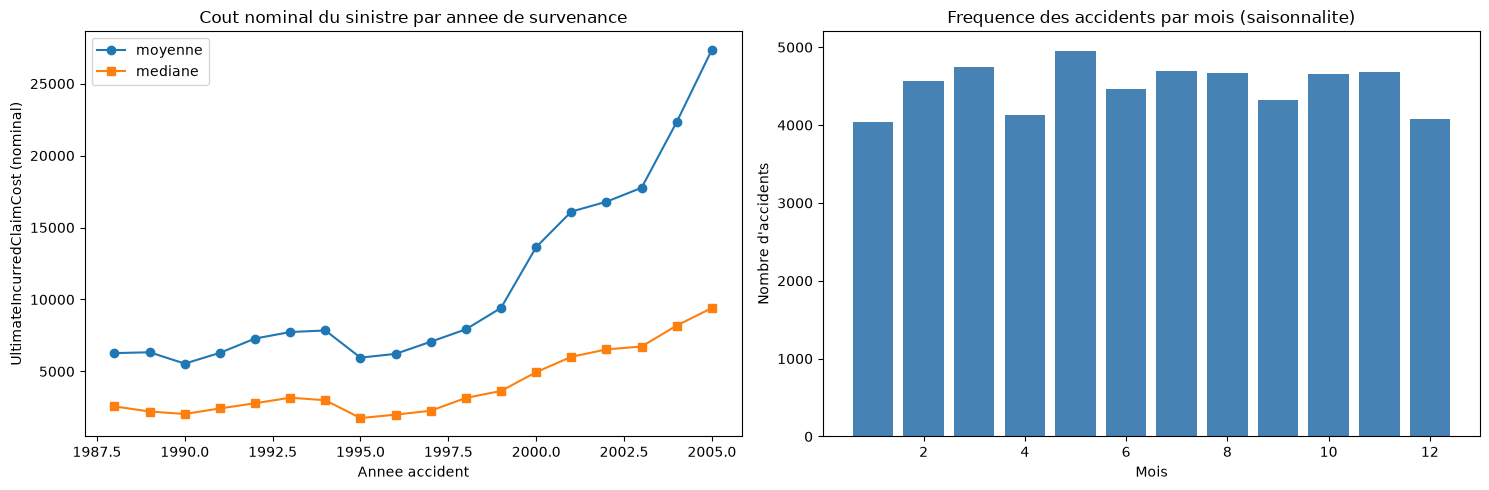


Croissance annuelle moyenne implicite du coût nominal (diagnostic) : 8.93 %


In [14]:
claim_df['AccidentYear'] = claim_df['DateTimeOfAccident'].dt.year
claim_df['AccidentMonth'] = claim_df['DateTimeOfAccident'].dt.month

yearly_cost = claim_df.groupby('AccidentYear')[target].agg(['mean', 'median', 'count'])
print(yearly_cost)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].plot(yearly_cost.index, yearly_cost['mean'], marker='o', label='moyenne')
axes[0].plot(yearly_cost.index, yearly_cost['median'], marker='s', label='médiane')
axes[0].set_title('Cout nominal du sinistre par année de survenance')
axes[0].set_xlabel('Annee accident')
axes[0].set_ylabel('UltimateIncurredClaimCost (nominal)')
axes[0].legend()

monthly_freq = claim_df.groupby('AccidentMonth').size()
axes[1].bar(monthly_freq.index, monthly_freq.values, color='steelblue')
axes[1].set_title('Frequence des accidents par mois (saisonnalité)')
axes[1].set_xlabel('Mois')
axes[1].set_ylabel("Nombre d'accidents")
plt.tight_layout()
plt.show()

# Tendance annuelle implicite (régression log-linéaire), a titre de diagnostic uniquement
from sklearn.linear_model import LinearRegression
trend_model = LinearRegression()
trend_model.fit(yearly_cost.index.values.reshape(-1, 1), np.log1p(yearly_cost['mean'].values))
implied_annual_growth = (np.expm1(trend_model.coef_[0]))
print('\nCroissance annuelle moyenne implicite du coût nominal (diagnostic) :', round(implied_annual_growth * 100, 2), '%')

**Ajustement d'inflation (trend actuariel)** : comparer directement un sinistre de 1988 et un sinistre de 2007 en dollars nominaux revient à comparer des grandeurs non homogènes - 10 000$ en 1988 ne représentent pas le même coût de soins qu'en 2007. La pratique actuarielle standard consiste a **trender** les sinistres historiques vers une année de référence commune à l'aide d'un indice externe, et non d'un indice recalcule sur la cible elle-même (ce qui serait circulaire).

On utilise l'indice **CPI Medical Care** (Bureau of Labor Statistics, U.S. City Average), valeurs annuelles moyennes 1988-2007, compilées via [in2013dollars.com/Medical-care/price-inflation](https://www.in2013dollars.com/Medical-care/price-inflation) (source primaire BLS). *Limite assumée* : ces valeurs sont reprises d'un agrégateur tiers plutôt que directement de la série BLS `CUUR0000SAM` ; pour une soumission réglementaire, il conviendrait de les resourcer directement auprès du BLS. Elles restent suffisamment fiables pour démontrer la méthodologie.

Chaque sinistre est ramene en **dollars équivalents 2007** (dernière année du portefeuille) via `cout_ajuste = cout_nominal x (indice_2007 / indice_annee_accident)`.

Facteur d'ajustement 1988 -> 2007 : 2.53 x
Facteur d'ajustement 2000 -> 2007 : 1.35 x


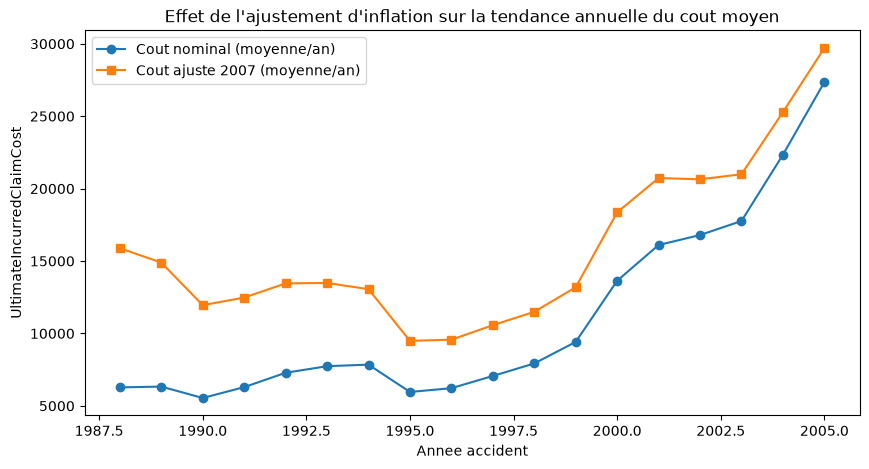

Croissance annuelle résiduelle après ajustement (diagnostic) : 4.02 %
(a comparer à 8.93 % avant ajustement, cf. cellule précédente)


In [15]:
# Indice CPI Medical Care (BLS, moyenne annuelle), source : in2013dollars.com/Medical-care/price-inflation
CPI_MEDICAL_CARE = {
    1988: 138.642, 1989: 149.250, 1990: 162.800, 1991: 177.017, 1992: 190.067,
    1993: 201.408, 1994: 211.017, 1995: 220.467, 1996: 228.225, 1997: 234.583,
    1998: 242.133, 1999: 250.583, 2000: 260.750, 2001: 272.758, 2002: 285.600,
    2003: 297.075, 2004: 310.133, 2005: 323.225, 2006: 336.183, 2007: 351.054,
}
REFERENCE_YEAR = 2007

claim_df['cpi_index'] = claim_df['AccidentYear'].map(CPI_MEDICAL_CARE)
claim_df['inflation_factor'] = CPI_MEDICAL_CARE[REFERENCE_YEAR] / claim_df['cpi_index']
claim_df[target + '_adj2007'] = claim_df[target] * claim_df['inflation_factor']

print('Facteur d\'ajustement 1988 -> 2007 :', round(CPI_MEDICAL_CARE[REFERENCE_YEAR] / CPI_MEDICAL_CARE[1988], 2), 'x')
print('Facteur d\'ajustement 2000 -> 2007 :', round(CPI_MEDICAL_CARE[REFERENCE_YEAR] / CPI_MEDICAL_CARE[2000], 2), 'x')

yearly_adj = claim_df.groupby('AccidentYear')[[target, target + '_adj2007']].mean()
yearly_adj.columns = ['nominal', 'ajuste_2007']

plt.figure(figsize=(10, 5))
plt.plot(yearly_adj.index, yearly_adj['nominal'], marker='o', label='Cout nominal (moyenne/an)')
plt.plot(yearly_adj.index, yearly_adj['ajuste_2007'], marker='s', label='Cout ajuste 2007 (moyenne/an)')
plt.title("Effet de l'ajustement d'inflation sur la tendance annuelle du coût moyen")
plt.xlabel('Annee accident')
plt.ylabel('UltimateIncurredClaimCost')
plt.legend()
plt.show()

trend_adj_model = LinearRegression()
trend_adj_model.fit(yearly_adj.index.values.reshape(-1, 1), np.log1p(yearly_adj['ajuste_2007'].values))
implied_annual_growth_adj = np.expm1(trend_adj_model.coef_[0])
print('Croissance annuelle résiduelle après ajustement (diagnostic) :', round(implied_annual_growth_adj * 100, 2), '%')
print('(a comparer a', round(implied_annual_growth * 100, 2), '% avant ajustement, cf. cellule précédente)')

### 4.5 Analyse textuelle de `ClaimDescription`

Avant de construire le flux NLP/agentique (Etape 3.3), on caractérise le corpus : longueur des descriptions et bigrammes les plus fréquents, afin de valider la pertinence d'une exploitation sémantique (au-dela d'un simple sac de mots).

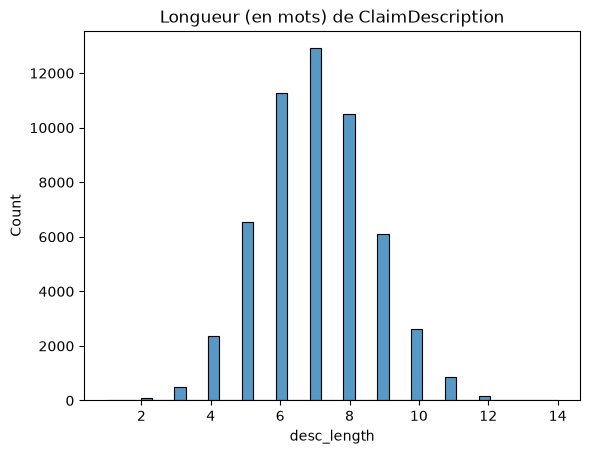

lower back - 9442
back strain - 6379
foreign body - 3880
strain lower - 3013
left hand - 2747
right shoulder - 2609
index finger - 2571
right hand - 2565
laceration left - 2334
right knee - 2193
lacerated left - 2029
left shoulder - 1877
right eye - 1747
lacerated right - 1739
laceration right - 1737
left eye - 1665
strain right - 1593
soft tissue - 1575
middle finger - 1571
left thumb - 1506


In [16]:
import collections
import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
from nltk.tokenize import word_tokenize

text_col = SCHEMA['text_feature']
claim_df['desc_length'] = claim_df[text_col].str.split().str.len()
sns.histplot(claim_df['desc_length'], bins=40)
plt.title('Longueur (en mots) de ClaimDescription')
plt.show()

all_desc = ' '.join(claim_df[text_col].tolist()).lower()
tokens = word_tokenize(all_desc, language='english')
bigrams = collections.Counter(nltk.ngrams(tokens, 2)).most_common(20)
for bigram, count in bigrams:
    print(' '.join(bigram), '-', count)

### 4.6 Synthese de l'EDA

- La cible est fortement asymétrique (skewness 37.6) : Pearson (0.39 pour `InitialIncurredCalimsCost`) sous-estime la relation réelle - Spearman est supérieur de +0.49 point, et l'information mutuelle confirme `InitialIncurredCalimsCost` comme prédicteur numérique dominant (MI = 0.91, PPS = 0.22, tous deux très au-dessus des autres variables numériques).
- **Analyse bivariée des catégorielles** : les 5 variables testées (`Gender`, `MaritalStatus`, `PartTimeFullTime`, `DependentChildren`, `DependentsOther`) montrent toutes une association statistiquement significative avec le coût (Kruskal-Wallis, p < 0.05). Observations métier notables : les femmes représentent 22.8% des sinistres mais un coût moyen plus élevé (12 878 vs 10 448 pour les hommes) ; les sinistres avec `DependentsOther` renseigne (0.9% des cas) ont un coût moyen près de 2x supérieur (22 006 vs 10 902).
- **Analyse temporelle et inflation** : le coût nominal moyen croit d'environ **8.9%/an** sur la période. Un ajustement par l'indice CPI Medical Care (BLS) ramene cette croissance résiduelle a **4.0%/an** - l'inflation médicale n'explique donc qu'environ la moitié de la tendance observée ; le reste peut refléter une immaturite des sinistres les plus récents (développement vers l'ultime non termine) ou une évolution réelle de la sévérité, a investiguer avec un actuaire reserving.
- Le score de gravité manquant sur `MaritalStatus` (29 cas) présente un coût moyen plus faible (5 326 vs 11 006) mais l'écart n'est pas statistiquement significatif au seuil de 5% (Mann-Whitney, p=0.08) - tendance suggestive, non concluante sur un si petit échantillon.
- Les bigrammes de `ClaimDescription` (ex. *lifting tyre*, *right arm*, *lower back*) montrent une structure sémantique exploitable (type de geste + partie du corps blessée) : cela motive le flux NLP/agentique de l'Etape 3.3.

## 5. Feature engineering commun

On derive des variables temporelles à partir des dates, puis on encode les variables catégorielles (one-hot). Ce jeu de features "tabulaire" sert de socle commun aux trois flux de modélisation. **Attention traçabilité** : les colonnes dérivées de l'analyse temporelle (`AccidentYear`, `AccidentMonth`, `cpi_index`, `inflation_factor`, `UltimateIncurredClaimCost_adj2007`) sont explicitement exclues de la matrice de features ci-dessous - elles ont vocation à rester des outils d'analyse EDA/sensibilité (Section 9.2), pas des prédicteurs (la dernière, en particulier, serait une fuite de données directe si elle etait laissée dans le jeu d'entraînement).

In [17]:
def generate_datetime_features(df: pd.DataFrame, date_cols: list) -> pd.DataFrame:
    df = df.copy()
    for col in date_cols:
        df[col + 'Year'] = df[col].dt.year
        df[col + 'Month'] = df[col].dt.month
        df[col + 'DayOfWeek'] = df[col].dt.dayofweek
        df[col + 'Weekend'] = (df[col].dt.dayofweek >= 5).astype(int)
    df['ReportDelayDays'] = (df[date_cols[1]] - df[date_cols[0]]).dt.days.clip(lower=0)
    return df


claim_df = generate_datetime_features(claim_df, SCHEMA['date_features'])

claim_encoded = pd.get_dummies(claim_df, columns=SCHEMA['cat_features'], drop_first=True)

# IMPORTANT : en plus des colonnes techniques habituelles, on exclut explicitement les
# colonnes dérivées ajoutées pendant l'EDA temporelle (Section 4.4quinquies) :
# 'AccidentYear'/'AccidentMonth' sont redondantes avec DateTimeOfAccidentYear/Month
# (déjà présentes ci-dessus), et surtout 'cpi_index', 'inflation_factor' et
# UltimateIncurredClaimCost_adj2007 sont des fonctions quasi déterministes de la cible
# elle-même : les laisser dans la matrice de features serait une fuite de données majeure.
EDA_DERIVED_COLS = ['AccidentYear', 'AccidentMonth', 'cpi_index', 'inflation_factor',
                     target + '_adj2007']
drop_cols = [SCHEMA['id_feature'], SCHEMA['text_feature']] + SCHEMA['date_features'] + EDA_DERIVED_COLS
claim_encoded = claim_encoded.drop(columns=drop_cols, errors='ignore')

print('shape après encodage:', claim_encoded.shape)
assert target + '_adj2007' not in claim_encoded.columns, 'Fuite de données : adj2007 encore present !'
claim_encoded.head()

shape après encodage: (54000, 24)


,Age,WeeklyWages,HoursWorkedPerWeek,DaysWorkedPerWeek,InitialIncurredCalimsCost,UltimateIncurredClaimCost,desc_length,DateTimeOfAccidentYear,DateTimeOfAccidentMonth,DateTimeOfAccidentDayOfWeek,DateTimeOfAccidentWeekend,DateReportedYear,DateReportedMonth,DateReportedDayOfWeek,DateReportedWeekend,ReportDelayDays,Gender_M,Gender_U,MaritalStatus_Missing,MaritalStatus_S,MaritalStatus_U,DependentChildren_Autre,DependentsOther_Autre,PartTimeFullTime_P
0,48,500.00,38.0,5,1500,4748.203388,9,2002,4,1,0,2002,7,4,0,86,True,False,False,False,False,False,False,False
1,43,509.34,37.5,5,5500,6326.285819,9,1999,1,3,0,1999,1,2,0,12,False,False,False,False,False,False,False,False
2,30,709.10,38.0,5,1700,2293.949087,7,1996,3,0,0,1996,4,6,1,20,True,False,False,False,True,False,False,False
3,41,555.46,38.0,5,15000,17786.487170,6,2005,6,2,0,2005,7,4,0,29,True,False,False,True,False,False,False,False
4,36,377.10,38.0,5,2800,4014.002925,11,1990,8,2,0,1990,9,3,0,28,True,False,False,False,False,False,False,False


In [18]:
# Split train/test - les index sont conservés pour aligner plus tard les features
# issues de l'autoencodeur et du flux NLP (évite toute fuite d'information).

y = claim_encoded[target]
X_base = claim_encoded.drop(columns=[target, 'desc_length'])

X_train_idx, X_test_idx = train_test_split(
    claim_encoded.index, test_size=0.2, random_state=RANDOM_STATE
)

X_train_base = X_base.loc[X_train_idx]
X_test_base = X_base.loc[X_test_idx]
y_train = y.loc[X_train_idx]
y_test = y.loc[X_test_idx]

print('Train:', X_train_base.shape, ' Test:', X_test_base.shape)

Train: (43200, 22)  Test: (10800, 22)


**Note méthodologique à priori (avant tout audit)** : les variables dérivées de `DateReported` (`ReportDelayDays`, `DateReportedYear/Month/DayOfWeek`) méritent une vigilance particulière des la conception, indépendamment de tout résultat empirique. Un outil pense pour estimer un coût des la première notification du sinistre ne devrait pas s'appuyer sur des variables qui dependent de la date de déclaration elle-même - c'est une source plausible de fuite de données ou, a minima, une variable dont la disponibilité au moment de la prédiction est douteuse. Cette vigilance est testée empiriquement plus loin (Section 10.2ter) via SHAP, permutation importance et ablation : l'audit écartera l'hypothèse de fuite au sens strict au profit d'un biais du critère de gain de XGBoost - mais la question est formulée ici, avant d'entrainer le moindre modèle, pour qu'elle ne soit pas une simple observation à posteriori.

## 6. Etape 3.1 - Flux Machine Learning : XGBoost + hyperparamétrage

**Correction majeure par rapport à la version précédente du projet** : l'absence de recherche d'hyperparamètres etait la principale faille identifiée. On implémenté ici une recherche systématique avec **Optuna** (optimisation bayesienne, `TPESampler`), préférée à un `GridSearchCV` exhaustif pour deux raisons justifiées :

1. L'espace de recherche (learning_rate, max_depth, n_estimators, subsample, colsample_bytree, min_child_weight) est continu/mixte : une grille discrète couvrirait mal cet espace ou coûterait très cher en nombre de combinaisons.
2. Optuna guide la recherche vers les zones prometteuses (contrairement à une grille qui explore uniformément), ce qui réduit le nombre d'entrainements nécessaires à qualité égale.

Chaque essai est evalue par validation croisée (5 folds) sur le RMSE, et le meilleur essai est trace (`study.best_params`, `study.best_value`) pour assurer la traçabilité demandée.

### 6.1 Modele de référence (baseline, sans tuning)

In [19]:
def evaluate_regression(y_true, y_pred, label=''):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    print(label, '- RMSE:', round(rmse, 2), ' MAE:', round(mae, 2))
    return {'label': label, 'rmse': rmse, 'mae': mae}


results = []

xgb_baseline = xgb.XGBRegressor(
    n_estimators=300, random_state=RANDOM_STATE, tree_method='hist'
)
xgb_baseline.fit(X_train_base, y_train)
pred_baseline = xgb_baseline.predict(X_test_base)
results.append(evaluate_regression(y_test, pred_baseline, 'XGBoost baseline (défaut)'))

XGBoost baseline (défaut) - RMSE: 28306.73  MAE: 9437.03


### 6.1bis Reference actuarielle classique : GLM Gamma (lien log)

Avant de pousser plus loin le gradient boosting, on établit une référence actuarielle standard : un **GLM Gamma à lien log**, la famille de référence pour modéliser une sévérité strictement positive et asymétrique à droite (`UltimateIncurredClaimCost` : minimum observé 122, aucune valeur nulle ou négative - condition nécessaire pour une loi Gamma). Ce modèle est entraine sur exactement les mêmes features que le baseline XGBoost (`X_train_base`), pour une comparaison équitable.

**Pourquoi pas un triangle de développement (Chain-Ladder, Bornhuetter-Ferguson) ?** Ces méthodes de provisionnement s'appliquent à des données agrégées par année de survenance et période de développement (un triangle), avec plusieurs valorisations successives d'un même cohort de sinistres au fil du temps. Le jeu de données utilise ici est structure par sinistre individuel, avec un seul montant ultime observe par sinistre et aucune date de valorisation intermédiaire : la structure en triangle nécessaire à Chain-Ladder/BF n'existe pas dans ces données. Le GLM Gamma reste en revanche directement pertinent : c'est l'approche généralisée des modèles de sévérité par sinistre en tarification IARD, bien avant l'arrivee du gradient boosting dans la pratique actuarielle.

In [20]:
from sklearn.linear_model import GammaRegressor

# Les variables continues (Age, WeeklyWages, InitialIncurredCalimsCost, les composantes
# DateTime*/DateReported*, etc.) et les indicatrices one-hot cohabitent dans X_train_base
# a des échelles très différentes. Un GLM Gamma à lien log, ajuste par descente de gradient,
# est numériquement instable dans ce cas : une première tentative sans traitement a divergé
# (RMSE de l'ordre de 1e28), et une simple standardisation ne suffisait pas non plus (RMSE
# encore de l'ordre de 1e8), a cause du skew extrême de InitialIncurredCalimsCost (skewness
# 26.9 sur les données brutes, avant même le skew de la cible elle-même) : quelques valeurs
# très extrêmes produisaient des z-scores énormes, qui explosent une fois exponentiées par
# le lien log. La pratique actuarielle standard pour un GLM de sévérité est justement de
# travailler en log sur les variables monétaires à queue lourde plutôt que sur leur échelle
# brute : InitialIncurredCalimsCost est donc log-transformée (log1p) avant standardisation,
# ce qui stabilise correctement l'ajustement.
glm_continuous_cols = [c for c in X_train_base.columns if X_train_base[c].nunique() > 2]

X_train_glm = X_train_base.copy()
X_test_glm = X_test_base.copy()
X_train_glm['InitialIncurredCalimsCost'] = np.log1p(X_train_glm['InitialIncurredCalimsCost'])
X_test_glm['InitialIncurredCalimsCost'] = np.log1p(X_test_glm['InitialIncurredCalimsCost'])

glm_scaler = StandardScaler()
X_train_glm[glm_continuous_cols] = glm_scaler.fit_transform(X_train_glm[glm_continuous_cols])
X_test_glm[glm_continuous_cols] = glm_scaler.transform(X_test_glm[glm_continuous_cols])

glm_gamma = GammaRegressor(alpha=1.0, max_iter=2000)
glm_gamma.fit(X_train_glm, y_train)
pred_glm = glm_gamma.predict(X_test_glm)
results.append(evaluate_regression(y_test, pred_glm, 'GLM Gamma (référence actuarielle, lien log)'))


GLM Gamma (référence actuarielle, lien log) - RMSE: 27578.61  MAE: 7721.07


**Lecture actuarielle des coefficients.** Contrairement à XGBoost, chaque coefficient du GLM se lit directement comme un effet multiplicatif sur le coût attendu (lien log : exp(coefficient)), sans recourir à SHAP. Les variables continues ayant du être standardisées pour la stabilité numérique du GLM (cellule précédente), leur effet se lit 'pour une hausse d'un écart-type' plutôt que 'par unite' ; les variables catégorielles (indicatrices), elles, restent sur leur échelle 0/1 d'origine et se lisent directement comme un rapport à la modalité de référence - c'est l'argument central en faveur du GLM pour un usage réglementaire ou une revue par un comité tarification.

In [21]:
glm_effects = pd.Series(glm_gamma.coef_, index=X_train_base.columns)
glm_multiplicative = np.exp(glm_effects).sort_values(ascending=False)

glm_categorical_effects = glm_multiplicative[[c for c in glm_multiplicative.index if c not in glm_continuous_cols]]
glm_continuous_effects = glm_multiplicative[glm_continuous_cols]

print("Variables catégorielles (indicatrices) - effet multiplicatif vs modalité de référence :")
print(glm_categorical_effects.sort_values(ascending=False))
print()
print("Variables continues (standardisées, InitialIncurredCalimsCost en log1p) - effet")
print("multiplicatif pour +1 écart-type :")
print(glm_continuous_effects.sort_values(ascending=False))


Variables catégorielles (indicatrices) - effet multiplicatif vs modalité de référence :
MaritalStatus_U              1.021691
DependentChildren_Autre      1.012066
PartTimeFullTime_P           1.010589
DateTimeOfAccidentWeekend    1.004516
DependentsOther_Autre        1.002233
Gender_U                     0.999998
MaritalStatus_Missing        0.999773
DateReportedWeekend          0.996239
Gender_M                     0.976067
MaritalStatus_S              0.965240
dtype: float64

Variables continues (standardisées, InitialIncurredCalimsCost en log1p) - effet
multiplicatif pour +1 écart-type :
InitialIncurredCalimsCost      1.708781
WeeklyWages                    1.138941
Age                            1.086198
DateReportedYear               1.062814
DateTimeOfAccidentYear         1.062250
ReportDelayDays                1.006749
DateReportedDayOfWeek          1.006526
DateTimeOfAccidentMonth        1.006312
DateTimeOfAccidentDayOfWeek    1.002361
DateReportedMonth              0.995394
H

**Resultat.** Le GLM Gamma sert de point de repère actuariel pour juger si la complexité additionnelle de XGBoost (et, plus loin, de l'autoencodeur et du NLP) se justifie réellement au regard du gain de RMSE - comparaison chiffrée en Section 9.

### 6.2 Recherche d'hyperparamètres avec Optuna

Fonction objectif : RMSE moyen en validation croisée (5 folds) sur le train set. Nombre d'essais fixe à 40 (compromis temps de calcul / qualité, documente en Etape 5 - Limites).

In [22]:
def make_objective(X, y):
    kfold = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

    def objective(trial):
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 200, 900, step=100),
            'max_depth': trial.suggest_int('max_depth', 3, 10),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'subsample': trial.suggest_float('subsample', 0.5, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
            'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
            'random_state': RANDOM_STATE,
            'tree_method': 'hist',
        }
        model = xgb.XGBRegressor(**params)
        scores = cross_val_score(model, X, y, cv=kfold, scoring='neg_root_mean_squared_error', n_jobs=-1)
        return -scores.mean()

    return objective


study = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study.optimize(make_objective(X_train_base, y_train), n_trials=40, show_progress_bar=True)

print('Meilleur RMSE (CV):', round(study.best_value, 2))
print('Meilleurs hyperparamètres:', study.best_params)

  0%|          | 0/40 [00:00<?, ?it/s]

Meilleur RMSE (CV): 28692.16
Meilleurs hyperparamètres: {'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.010331579605798552, 'subsample': 0.9345096954319009, 'colsample_bytree': 0.8752596392842559, 'min_child_weight': 5}


XGBoost + Optuna (baseline features) - RMSE: 25813.09  MAE: 7672.78


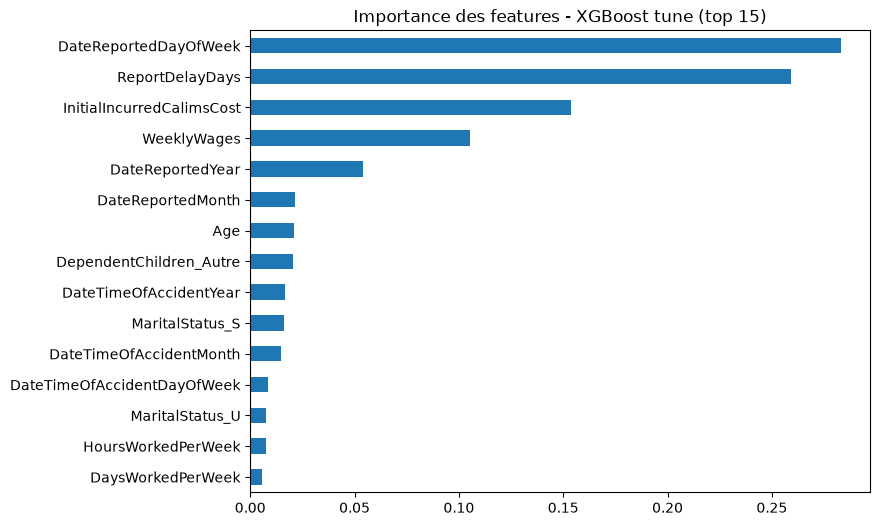

In [23]:
best_params = dict(study.best_params, random_state=RANDOM_STATE, tree_method='hist')
xgb_tuned = xgb.XGBRegressor(**best_params)
xgb_tuned.fit(X_train_base, y_train)
pred_tuned = xgb_tuned.predict(X_test_base)
results.append(evaluate_regression(y_test, pred_tuned, 'XGBoost + Optuna (baseline features)'))

importances = pd.Series(xgb_tuned.feature_importances_, index=X_train_base.columns)
importances.sort_values(ascending=False).head(15).plot(kind='barh', figsize=(8, 6))
plt.title("Importance des features - XGBoost tune (top 15)")
plt.gca().invert_yaxis()
plt.show()

### 6.3 Comparaison avec une recherche par grille (`GridSearchCV`)

A titre de comparaison méthodologique (et pour illustrer pourquoi Optuna est retenu comme approche principale), on exécute une grille restreinte sur les deux hyperparamètres les plus influents (`max_depth`, `learning_rate`). Une grille exhaustive sur les 6 hyperparamètres serait beaucoup trop coûteuse (des milliers de combinaisons).

In [24]:
param_grid = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
}
grid_model = xgb.XGBRegressor(n_estimators=400, random_state=RANDOM_STATE, tree_method='hist')
grid_search = GridSearchCV(grid_model, param_grid, cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1)
grid_search.fit(X_train_base, y_train)

print('Meilleurs paramètres (grille):', grid_search.best_params_)
pred_grid = grid_search.best_estimator_.predict(X_test_base)
results.append(evaluate_regression(y_test, pred_grid, 'XGBoost + GridSearchCV (comparaison)'))

Meilleurs paramètres (grille): {'learning_rate': 0.01, 'max_depth': 3}
XGBoost + GridSearchCV (comparaison) - RMSE: 26904.67  MAE: 7669.36


### 6.4 Comparaison avec une seconde famille de modèles : LightGBM

Les conseils méthodologiques du sujet insistent sur le fait d'"aborder le problème sous plusieurs angles" en testant plusieurs modèles. On ajoute donc **LightGBM** (gradient boosting base sur un growth histogram/leaf-wise, plus rapide que XGBoost sur de gros volumes), avec sa propre recherche Optuna (20 essais, budget réduit pour la comparaison) sur un espace d'hyperparamètres équivalent.

In [25]:
def make_lgb_objective(X, y):
    kfold = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

    def objective(trial):
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 200, 900, step=100),
            'num_leaves': trial.suggest_int('num_leaves', 15, 127),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'subsample': trial.suggest_float('subsample', 0.5, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
            'min_child_samples': trial.suggest_int('min_child_samples', 5, 50),
            'random_state': RANDOM_STATE,
            'verbosity': -1,
        }
        model = lgb.LGBMRegressor(**params)
        scores = cross_val_score(model, X, y, cv=kfold, scoring='neg_root_mean_squared_error', n_jobs=-1)
        return -scores.mean()

    return objective


lgb_study = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
lgb_study.optimize(make_lgb_objective(X_train_base, y_train), n_trials=20, show_progress_bar=True)

lgb_best_params = dict(lgb_study.best_params, random_state=RANDOM_STATE, verbosity=-1)
lgb_tuned = lgb.LGBMRegressor(**lgb_best_params)
lgb_tuned.fit(X_train_base, y_train)
pred_lgb = lgb_tuned.predict(X_test_base)
results.append(evaluate_regression(y_test, pred_lgb, 'LightGBM + Optuna (baseline features)'))

print('\nMeilleurs hyperparamètres LightGBM:', lgb_study.best_params)
model_comparison_df = pd.DataFrame([r for r in results if 'baseline features' in r['label'] or 'défaut' in r['label'] or 'GridSearchCV' in r['label']])
model_comparison_df

  0%|          | 0/20 [00:00<?, ?it/s]

LightGBM + Optuna (baseline features) - RMSE: 25994.66  MAE: 7729.36

Meilleurs hyperparamètres LightGBM: {'n_estimators': 600, 'num_leaves': 34, 'learning_rate': 0.012476394272569451, 'subsample': 0.9744427686266666, 'colsample_bytree': 0.9828160165372797, 'min_child_samples': 42}


,label,rmse,mae
0,XGBoost baseline (défaut),28306.733138,9437.033794
1,XGBoost + Optuna (baseline features),25813.086344,7672.781500
2,XGBoost + GridSearchCV (comparaison),26904.672797,7669.363156
3,LightGBM + Optuna (baseline features),25994.658818,7729.355140


### 6.5 Robustesse de l'estimation : intervalle de confiance par validation croisée répétée

Un seul split train/test (Section 6.1) donne une estimation ponctuelle du RMSE, sensible au hasard du split. On quantifie la variabilité de cette estimation par une **validation croisée répétée** (5 folds x 5 répétitions = 25 estimations) sur le modèle XGBoost tune, pour obtenir une moyenne et un écart-type plutôt qu'un chiffre unique.

RMSE (25 estimations, 5x5 CV) : moyenne = 28484.62  écart-type = 10345.43
Intervalle (moyenne +/- 2 écarts-types) : [ 7793.75 , 49175.49 ]


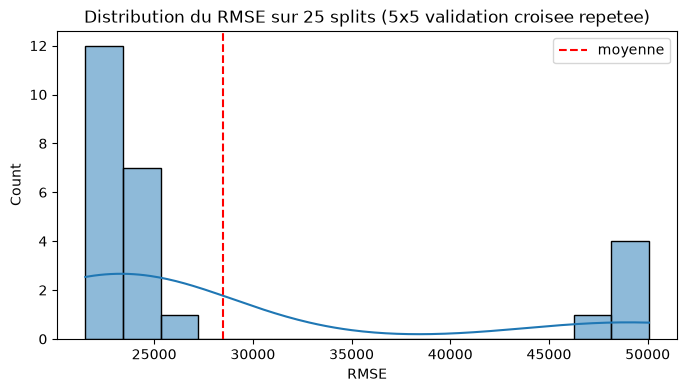

In [26]:
rkf = RepeatedKFold(n_splits=5, n_repeats=5, random_state=RANDOM_STATE)
xgb_for_cv = xgb.XGBRegressor(**best_params)
cv_scores = -cross_val_score(
    xgb_for_cv, X_train_base, y_train, cv=rkf, scoring='neg_root_mean_squared_error', n_jobs=-1
)

print('RMSE (25 estimations, 5x5 CV) : moyenne =', round(cv_scores.mean(), 2),
      ' écart-type =', round(cv_scores.std(), 2))
print('Intervalle (moyenne +/- 2 écarts-types) : [',
      round(cv_scores.mean() - 2 * cv_scores.std(), 2), ',',
      round(cv_scores.mean() + 2 * cv_scores.std(), 2), ']')

plt.figure(figsize=(8, 4))
sns.histplot(cv_scores, bins=15, kde=True)
plt.axvline(cv_scores.mean(), color='red', linestyle='--', label='moyenne')
plt.title('Distribution du RMSE sur 25 splits (5x5 validation croisée répétée)')
plt.xlabel('RMSE')
plt.legend()
plt.show()

## 7. Etape 3.2 - Flux Deep Learning : Autoencodeur pour la détection d'anomalies

**Objectif** : détecter en non-supervisé les sinistres dont les caractéristiques tabulaires sont atypiques, puis réinjecter cette information comme feature explicative dans XGBoost.

**Architecture** : encodeur/décodeur symétrique de couches `Dense` **64 -> 32 -> 16 -> 32 -> 64**, activation `relu` sur les couches cachées et linéaire en sortie (reconstruction de données standardisées). L'autoencodeur est entraine **uniquement sur le train set** (comme tout estimateur) pour éviter la fuite d'information.

**Score d'anomalie** : erreur quadratique moyenne de reconstruction MSE_i = (1/n) * sum_j (x_ij - x_ij_hat)^2. Les sinistres dont l'erreur dépasse le 99e percentile (observe sur le train) sont considérés comme anormaux.

In [27]:
ae_scaler = StandardScaler()
X_train_ae = ae_scaler.fit_transform(X_train_base)
X_test_ae = ae_scaler.transform(X_test_base)

n_features = X_train_ae.shape[1]

autoencoder = keras.Sequential([
    layers.Input(shape=(n_features,)),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(16, activation='relu', name='bottleneck'),
    layers.Dense(32, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(n_features, activation='linear'),
])
autoencoder.compile(optimizer='adam', loss='mse')
autoencoder.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck (Dense)              │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 22)             │         1,430 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,166 (31.90 KB)

 Trainable params: 8,166 (31.90 KB)

 Non-trainable params: 0 (0.00 B)

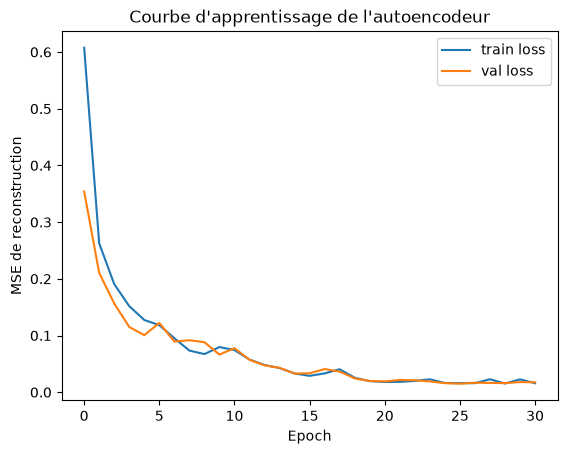

In [28]:
early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = autoencoder.fit(
    X_train_ae, X_train_ae,
    validation_split=0.1,
    epochs=100,
    batch_size=256,
    callbacks=[early_stop],
    verbose=0,
)

plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.xlabel('Epoch')
plt.ylabel('MSE de reconstruction')
plt.title("Courbe d'apprentissage de l'autoencodeur")
plt.legend()
plt.show()

Seuil d'anomalie (99e percentile, train): 0.1759


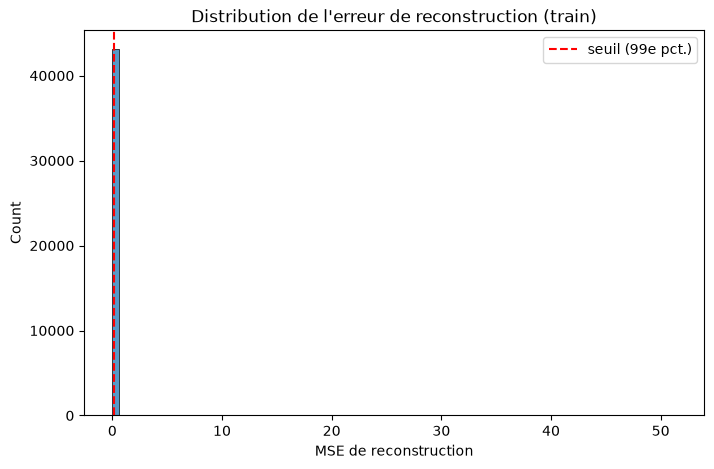

Anomalies détectées - train: 432 / 43200
Anomalies détectées - test: 112 / 10800


In [29]:
def reconstruction_mse(model, X):
    X_hat = model.predict(X, verbose=0)
    return np.mean(np.square(X - X_hat), axis=1)


train_recon_error = reconstruction_mse(autoencoder, X_train_ae)
test_recon_error = reconstruction_mse(autoencoder, X_test_ae)

anomaly_threshold = np.percentile(train_recon_error, 99)
print("Seuil d'anomalie (99e percentile, train):", round(anomaly_threshold, 4))

plt.figure(figsize=(8, 5))
sns.histplot(train_recon_error, bins=80)
plt.axvline(anomaly_threshold, color='red', linestyle='--', label='seuil (99e pct.)')
plt.title("Distribution de l'erreur de reconstruction (train)")
plt.xlabel('MSE de reconstruction')
plt.legend()
plt.show()

# On conservé une copie "baseline pure" (sans feature AE) pour la comparaison
# par ablation de l'étape 9, puis on crée la version enrichie par l'autoencodeur.
X_train_base_only = X_train_base.copy()
X_test_base_only = X_test_base.copy()

X_train_ae_feat = X_train_base_only.assign(
    ae_anomaly_score=train_recon_error, ae_is_anomaly=(train_recon_error > anomaly_threshold).astype(int)
)
X_test_ae_feat = X_test_base_only.assign(
    ae_anomaly_score=test_recon_error, ae_is_anomaly=(test_recon_error > anomaly_threshold).astype(int)
)

# X_train_base / X_test_base deviennent la référence "avec AE" utilisée pour la suite du notebook.
X_train_base = X_train_ae_feat
X_test_base = X_test_ae_feat

print('Anomalies détectées - train:', X_train_base['ae_is_anomaly'].sum(), '/', len(X_train_base))
print('Anomalies détectées - test:', X_test_base['ae_is_anomaly'].sum(), '/', len(X_test_base))

In [30]:
# Les sinistres détectés comme anormaux sont-ils aussi les plus coûteux ?
anomaly_cost_check = pd.DataFrame({
    'cost': y_train,
    'is_anomaly': X_train_base['ae_is_anomaly'],
})
print(anomaly_cost_check.groupby('is_anomaly')['cost'].describe())

              count          mean           std         min          25%  \
is_anomaly                                                                 
0           42768.0  10816.553491  33704.535604  121.886805   923.165593   
1             432.0  29807.634442  62142.626320  248.900168  2485.368370   

                    50%          75%           max  
is_anomaly                                          
0           3331.312513   8136.08882  4.027136e+06  
1           7441.482146  26743.41188  5.164342e+05  


### 7.3 Comparaison avec une méthode classique : Isolation Forest

Un autoencodeur n'est pas la seule méthode de détection d'anomalies non supervisée. Pour éviter de conclure trop vite à sa supériorité, on l'oppose a **Isolation Forest** (méthode d'ensemble classique, sans deep learning), configurée avec la même contamination cible (1%, cohérente avec le seuil au 99e percentile de l'autoencodeur), sur les mêmes features (`X_train_base_only`).

In [31]:
iso_forest = IsolationForest(contamination=0.01, random_state=RANDOM_STATE, n_jobs=-1)
iso_forest.fit(X_train_base_only)

if_train_flag = (iso_forest.predict(X_train_base_only) == -1).astype(int)
if_test_flag = (iso_forest.predict(X_test_base_only) == -1).astype(int)

print('Anomalies Isolation Forest - train:', if_train_flag.sum(), '/', len(if_train_flag))

ae_train_flag = X_train_base['ae_is_anomaly'].values
overlap = pd.crosstab(
    pd.Series(ae_train_flag, name='Autoencodeur'),
    pd.Series(if_train_flag, name='Isolation Forest'),
)
print('\nTable de contingence (train) :')
print(overlap)

jaccard = (
    ((ae_train_flag == 1) & (if_train_flag == 1)).sum()
    / max(((ae_train_flag == 1) | (if_train_flag == 1)).sum(), 1)
)
print('\nIndice de Jaccard (accord entre les deux méthodes):', round(jaccard, 3))

cost_by_method = pd.DataFrame({
    'cost': y_train.values,
    'ae_only': (ae_train_flag == 1) & (if_train_flag == 0),
    'if_only': (ae_train_flag == 0) & (if_train_flag == 1),
    'both': (ae_train_flag == 1) & (if_train_flag == 1),
    'neither': (ae_train_flag == 0) & (if_train_flag == 0),
})
for group in ['ae_only', 'if_only', 'both', 'neither']:
    subset = cost_by_method.loc[cost_by_method[group], 'cost']
    print(f'{group}: n={len(subset)}, coût moyen={subset.mean():.0f}')

Anomalies Isolation Forest - train: 432 / 43200

Table de contingence (train) :
Isolation Forest      0    1
Autoencodeur                
0                 42430  338
1                   338   94

Indice de Jaccard (accord entre les deux méthodes): 0.122
ae_only: n=338, coût moyen=25315
if_only: n=338, coût moyen=23800
both: n=94, coût moyen=45964
neither: n=42430, coût moyen=10713


## 8. Etape 3.3 - Flux NLP / IA Generative sur `ClaimDescription`

**Objectif** : transformer la description libre du sinistre (ex. *"LIFTING TYRE INJURY TO RIGHT ARM"*) en features numériques exploitables par XGBoost.

Deux briques complémentaires sont implémentées :

1. **Embeddings denses** via `SentenceTransformer('all-MiniLM-L6-v2')`, réduits par PCA à un petit nombre de composantes (évite l'explosion dimensionnelle et le sur-apprentissage face aux 384 dimensions brutes).
2. **Agent de scoring de gravité (1 à 3)** : un agent LLM reçoit l'instruction *"En tant qu'expert médical, analyse cette description de sinistre et classe la gravité potentielle sur une échelle de 1 à 3"*. Pour des raisons de coût/latence documentées en Etape 5, l'agent réel (API) est démontre sur un **échantillon réduit** (20 sinistres) ; le score est **généralisé à l'ensemble du jeu de données par une heuristique lexicale de repli** (mots-clés de gravité), qui sert de proxy peu coûteux et reproductible sans clé API.

In [32]:
from sentence_transformers import SentenceTransformer

embedder = SentenceTransformer('all-MiniLM-L6-v2')
descriptions = claim_df[SCHEMA['text_feature']].tolist()
embeddings = embedder.encode(descriptions, show_progress_bar=True, batch_size=128)
print('Embeddings shape:', embeddings.shape)

# claim_df conservé son index d'origine (0..N-1) tout au long du notebook,
# donc X_train_idx peut être utilisé directement comme indexeur positionnel du array numpy.
N_PCA_COMPONENTS = 10
pca = PCA(n_components=N_PCA_COMPONENTS, random_state=RANDOM_STATE)
pca.fit(embeddings[X_train_idx])
embeddings_pca = pca.transform(embeddings)

emb_cols = ['desc_emb_pca_' + str(i) for i in range(N_PCA_COMPONENTS)]
emb_df = pd.DataFrame(embeddings_pca, columns=emb_cols, index=claim_df.index)
print('Variance expliquee cumulee:', round(pca.explained_variance_ratio_.sum() * 100, 1), '%')

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/422 [00:00<?, ?it/s]

Embeddings shape: (54000, 384)


Variance expliquee cumulee: 45.2 %


### 8.2 Exploration non supervisée : clustering sémantique des descriptions

Avant de réduire `ClaimDescription` a un unique score de gravité, on explore la structure latente des embeddings par **clustering** (K-Means, nombre de clusters choisi par score de silhouette, et HDBSCAN en comparaison car il ne suppose pas une forme sphérique des clusters et gère le bruit). Une projection **t-SNE** en 2D permet de visualiser ces clusters et de les confronter au coût du sinistre.

In [33]:
candidate_k = [3, 4, 5, 6, 8]
silhouette_scores = []
for k in candidate_k:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels_k = km.fit_predict(embeddings_pca)
    sil = silhouette_score(embeddings_pca, labels_k, sample_size=5000, random_state=RANDOM_STATE)
    silhouette_scores.append(sil)
    print(f'k={k}: silhouette={sil:.3f}')

best_k = candidate_k[int(np.argmax(silhouette_scores))]
print('\nMeilleur k (silhouette):', best_k)

kmeans_final = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10)
kmeans_labels = kmeans_final.fit_predict(embeddings_pca)

hdb = hdbscan.HDBSCAN(min_cluster_size=200, min_samples=10)
hdbscan_labels = hdb.fit_predict(embeddings_pca)
n_hdb_clusters = len(set(hdbscan_labels)) - (1 if -1 in hdbscan_labels else 0)
print('HDBSCAN : ', n_hdb_clusters, 'clusters,', (hdbscan_labels == -1).sum(), 'points de bruit (non assignes)')

k=3: silhouette=0.216


k=4: silhouette=0.247


k=5: silhouette=0.246


k=6: silhouette=0.221


k=8: silhouette=0.223

Meilleur k (silhouette): 4


HDBSCAN :  24 clusters, 36659 points de bruit (non assignes)


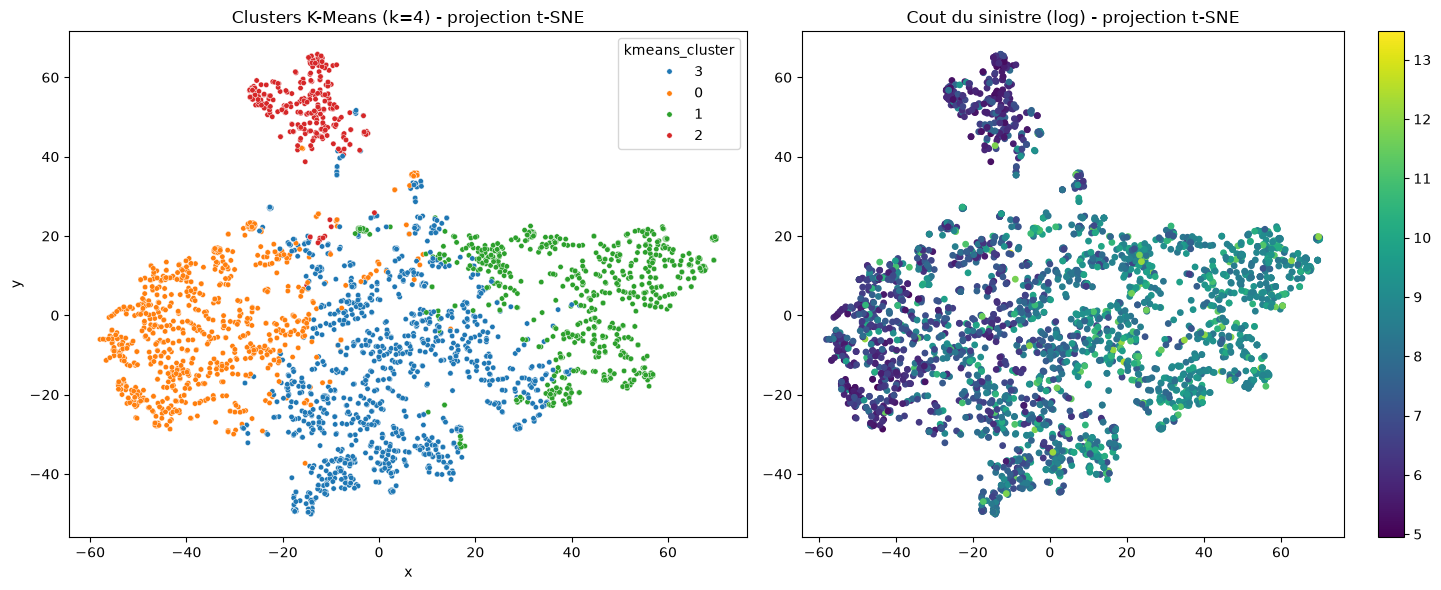

         count          mean       median
cluster                                  
0        15046   4749.872407   964.249081
1        13428  18459.805948  7369.164684
2         4684   2389.735317   496.499167
3        20842  12649.628653  3941.608547


In [34]:
tsne_sample_idx = np.random.RandomState(RANDOM_STATE).choice(len(embeddings_pca), size=3000, replace=False)
tsne = TSNE(n_components=2, perplexity=35, init='pca', random_state=RANDOM_STATE)
tsne_coords = tsne.fit_transform(embeddings_pca[tsne_sample_idx])

tsne_df = pd.DataFrame({
    'x': tsne_coords[:, 0],
    'y': tsne_coords[:, 1],
    'kmeans_cluster': kmeans_labels[tsne_sample_idx].astype(str),
    'log_cost': np.log1p(claim_df[target].values[tsne_sample_idx]),
})

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.scatterplot(data=tsne_df, x='x', y='y', hue='kmeans_cluster', palette='tab10', s=15, ax=axes[0])
axes[0].set_title(f'Clusters K-Means (k={best_k}) - projection t-SNE')
sc = axes[1].scatter(tsne_df['x'], tsne_df['y'], c=tsne_df['log_cost'], cmap='viridis', s=15)
axes[1].set_title('Cout du sinistre (log) - projection t-SNE')
plt.colorbar(sc, ax=axes[1])
plt.tight_layout()
plt.show()

print(pd.DataFrame({'cluster': kmeans_labels, 'cost': claim_df[target].values}).groupby('cluster')['cost'].agg(['count', 'mean', 'median']))

### 8.3 Agent de scoring de gravité (1 = léger, 2 = modéré, 3 = sévère)

Trois méthodes de complexité croissante sont comparées, pour ne pas se limiter à une heuristique simpliste tout en restant gratuit et reproductible à l'échelle des 54 000 sinistres :

1. **Heuristique lexicale** (mots-clés) : rapide, transparente, mais grossière et sujette au biais de vocabulaire.
2. **Zero-shot par similarité d'embeddings** : chaque description est comparée (similarité cosinus) a des phrases-ancres décrivant chaque niveau de gravité, dans le même espace sémantique `SentenceTransformer` que celui déjà calcule en 8.1. C'est une forme réelle de raisonnement sémantique (zero-shot), sans mots-clés fixes, applicable **sans coût ni clé API sur les 54 000 sinistres**, et constitue la **méthode retenue en production** pour la feature `severity_score`.
3. **Agent LLM réel** (API OpenAI) : démontre sur un échantillon de 20 sinistres, utilise ici comme **etalon de référence** pour valider la méthode 2 (accord mesure par le kappa de Cohen).

In [35]:
SEVERITY_KEYWORDS = {
    3: ['fracture', 'amputation', 'crush', 'burn', 'head', 'spine', 'death', 'severe', 'multiple'],
    2: ['tear', 'sprain', 'strain', 'dislocation', 'laceration', 'back', 'shoulder', 'knee'],
    1: ['bruise', 'contusion', 'abrasion', 'minor', 'sore'],
}


def severity_heuristic(description: str) -> int:
    """Score de gravité 1-3 basé sur la présence de mots-clés médicaux.

    Proxy peu coûteux de l'agent LLM decrit dans le brief : sert de repli
    reproductible et gratuit applicable à l'ensemble du corpus.
    """
    text = str(description).lower()
    for level in (3, 2, 1):
        if any(keyword in text for keyword in SEVERITY_KEYWORDS[level]):
            return level
    return 1


claim_df['severity_score'] = claim_df[SCHEMA['text_feature']].apply(severity_heuristic)
claim_df['severity_score'].value_counts().sort_index()

severity_score
1    18660
2    29185
3     6155
Name: count, dtype: int64

In [36]:
SEVERITY_ANCHORS = {
    1: 'minor injury, small bruise or abrasion, no lost time, quick recovery expected',
    2: 'moderate injury such as a sprain, strain or laceration requiring medical treatment',
    3: 'severe injury such as a fracture, amputation, burn or head/spine trauma with long-term consequences',
}

anchor_texts = list(SEVERITY_ANCHORS.values())
anchor_levels = list(SEVERITY_ANCHORS.keys())
anchor_embeddings = embedder.encode(anchor_texts)


def cosine_similarity_matrix(A, B):
    A_norm = A / np.linalg.norm(A, axis=1, keepdims=True)
    B_norm = B / np.linalg.norm(B, axis=1, keepdims=True)
    return A_norm @ B_norm.T


similarity_to_anchors = cosine_similarity_matrix(embeddings, anchor_embeddings)
severity_score_zeroshot = np.array(anchor_levels)[similarity_to_anchors.argmax(axis=1)]

claim_df['severity_score_zeroshot'] = severity_score_zeroshot
print('Zero-shot (embeddings) - distribution :')
print(claim_df['severity_score_zeroshot'].value_counts().sort_index())

agreement_heuristic_zeroshot = (claim_df['severity_score'] == claim_df['severity_score_zeroshot']).mean()
kappa_heuristic_zeroshot = cohen_kappa_score(claim_df['severity_score'], claim_df['severity_score_zeroshot'])
print('\nAccord heuristique vs zero-shot :', round(agreement_heuristic_zeroshot * 100, 1), '%')
print('Kappa de Cohen (heuristique vs zero-shot) :', round(kappa_heuristic_zeroshot, 3))

# Le zero-shot par embeddings devient la feature de gravité retenue en production.
claim_df['severity_score_heuristic'] = claim_df['severity_score']
claim_df['severity_score'] = claim_df['severity_score_zeroshot']

Zero-shot (embeddings) - distribution :
severity_score_zeroshot
1     5113
2    43816
3     5071
Name: count, dtype: int64

Accord heuristique vs zero-shot : 61.5 %
Kappa de Cohen (heuristique vs zero-shot) : 0.257


**Note de conformité (RGPD, avant d'appeler l'API).** `ClaimDescription` révèle par nature des informations de santé (nature de la blessure, partie du corps touchée) : au sens de l'article 9 du RGPD, ce sont des données à caractère personnel d'une catégorie particulière des lors qu'elles se rattachent à un assuré identifié ou identifiable - ce qui est le cas ici puisque chaque description est liée, dans le système d'information de l'assureur, a un `ClaimNumber` et donc à une personne. L'appel ci-dessous n'envoie à l'API OpenAI que le texte libre (ni `ClaimNumber`, ni nom, ni autre identifiant direct), ce qui réduit mais n'annule pas le risque de réidentification - certaines descriptions très spécifiques pourraient rester rattachables à un individu. Ce n'est pas un détail à reléguer aux limites du projet : en l'etat, ce flux ne serait **pas deployable en production** sans l'une des garanties suivantes, absentes ici : (i) un contrat de sous-traitance RGPD avec hébergement UE (ex. Azure OpenAI en region européenne), (ii) un LLM auto-hébergé (poids ouverts) ne faisant sortir aucune donnée du périmètre de l'assureur, ou (iii) une anonymisation du texte validée par un DPO, plus robuste qu'un simple retrait des identifiants directs. C'est précisément pour cette raison que la démonstration reste gâtée derrière `OPENAI_API_KEY` (absente par défaut) et limitée à un tout petit échantillon, jamais exécutée sur le portefeuille complet.

In [37]:
USE_REAL_LLM_AGENT = bool(os.environ.get('OPENAI_API_KEY'))

AGENT_SYSTEM_PROMPT = (
    "En tant qu'expert médical en assurance accidents du travail, analyse cette "
    "description de sinistre et classe la gravité potentielle sur une échelle de 1 a 3 "
    "(1 = léger, 2 = modéré, 3 = sévère). Réponds uniquement par le chiffre."
)


def llm_severity_agent(description: str, client) -> int:
    """Appelle un agent LLM (API OpenAI) pour scorer la gravité d'un sinistre.

    N'est exécuté que si une clé API est présente dans l'environnement
    (jamais saisie ni stockee dans ce notebook).
    """
    response = client.chat.completions.create(
        model='gpt-4o-mini',
        messages=[
            {'rôle': 'system', 'content': AGENT_SYSTEM_PROMPT},
            {'rôle': 'user', 'content': description},
        ],
        temperature=0,
        max_tokens=2,
    )
    return int(response.choices[0].message.content.strip()[0])


if USE_REAL_LLM_AGENT:
    from openai import OpenAI
    client = OpenAI()
    sample = claim_df.sample(20, random_state=RANDOM_STATE)
    sample = sample.assign(
        llm_severity=sample[SCHEMA['text_feature']].apply(lambda d: llm_severity_agent(d, client))
    )
    print(sample[[SCHEMA['text_feature'], 'severity_score_heuristic', 'severity_score_zeroshot', 'llm_severity']])

    kappa_llm_zeroshot = cohen_kappa_score(sample['llm_severity'], sample['severity_score_zeroshot'])
    kappa_llm_heuristic = cohen_kappa_score(sample['llm_severity'], sample['severity_score_heuristic'])
    print('\nSur cet échantillon de 20, kappa (LLM réel vs zero-shot embeddings):', round(kappa_llm_zeroshot, 3))
    print('Sur cet échantillon de 20, kappa (LLM réel vs heuristique lexicale):', round(kappa_llm_heuristic, 3))
    print("-> permet de valider empiriquement que le zero-shot est un meilleur proxy du LLM que l'heuristique.")
else:
    print('OPENAI_API_KEY absent : démonstration agent LLM ignorée.')
    print('La feature severity_score en production reste le zero-shot par embeddings (Section 8.3, méthode 2),')
    print("qui ne nécessite pas d'appel API et couvre les 54 000 sinistres.")

OPENAI_API_KEY absent : démonstration agent LLM ignorée.
La feature severity_score en production reste le zero-shot par embeddings (Section 8.3, méthode 2),
qui ne nécessite pas d'appel API et couvre les 54 000 sinistres.


In [38]:
# Assemblage des features NLP (embeddings PCA + score de gravité) alignees sur les
# index train/test déjà définis à l'étape 5.
nlp_features_df = emb_df.join(claim_df['severity_score'])

X_train_nlp = X_train_base.join(nlp_features_df.loc[X_train_idx])
X_test_nlp = X_test_base.join(nlp_features_df.loc[X_test_idx])

print('Features avec NLP - train:', X_train_nlp.shape, ' test:', X_test_nlp.shape)
X_train_nlp.head()

Features avec NLP - train: (43200, 35)  test: (10800, 35)


,Age,WeeklyWages,HoursWorkedPerWeek,DaysWorkedPerWeek,InitialIncurredCalimsCost,DateTimeOfAccidentYear,DateTimeOfAccidentMonth,DateTimeOfAccidentDayOfWeek,DateTimeOfAccidentWeekend,DateReportedYear,DateReportedMonth,DateReportedDayOfWeek,DateReportedWeekend,ReportDelayDays,Gender_M,Gender_U,MaritalStatus_Missing,MaritalStatus_S,MaritalStatus_U,DependentChildren_Autre,DependentsOther_Autre,PartTimeFullTime_P,ae_anomaly_score,ae_is_anomaly,desc_emb_pca_0,desc_emb_pca_1,desc_emb_pca_2,desc_emb_pca_3,desc_emb_pca_4,desc_emb_pca_5,desc_emb_pca_6,desc_emb_pca_7,desc_emb_pca_8,desc_emb_pca_9,severity_score
5688,34,200.00,38.0,5,350,1996,6,1,0,1996,7,1,0,6,True,False,False,False,False,False,False,False,0.001157,0,-0.473308,0.064717,0.111713,0.025889,0.119740,-0.120347,0.155733,0.014612,0.011069,-0.015525,2
40513,40,431.40,38.0,5,65000,2003,2,0,0,2003,4,3,0,44,True,False,False,False,True,False,False,False,0.008717,0,0.512199,0.099669,0.116541,0.008820,0.035893,0.072940,0.186516,-0.012825,-0.221163,-0.042310,2
17163,26,435.70,40.0,5,6000,1993,5,1,0,1993,6,1,0,27,True,False,False,True,False,False,False,False,0.001133,0,-0.292281,0.176297,-0.100983,0.279233,-0.146093,0.022591,0.110137,0.132480,0.060347,-0.087005,2
39180,34,826.92,40.0,5,7800,1995,10,1,0,1995,11,1,0,27,True,False,False,False,False,False,False,False,0.001207,0,-0.037885,0.113290,-0.010924,0.194705,0.183458,0.182493,-0.050605,0.257180,-0.024448,-0.026115,2
7905,24,728.05,40.0,5,25000,2000,3,3,0,2000,3,6,1,23,True,False,False,False,True,False,False,False,0.012821,0,0.584241,0.153223,0.115989,-0.011359,0.018774,0.004602,0.011032,-0.276120,0.027622,-0.174332,2


### 8.4 Agent de triage avec appel d'outils (function calling)

La sous-section 8.3 comparait trois **méthodes de classification** de gravité (heuristique, zero-shot, LLM). Aucune des trois n'est un agent au sens strict : classer un texte selon un score fixe ne requiert ni décision autonome, ni usage d'outils. On implémente ici un **véritable agent à appel d'outils**, sur le modèle de la boucle agentique (`tools`, `tool_calls`, exécution locale, re-injection du résultat) : l'agent reçoit uniquement la description libre du sinistre et doit **décider lui-même** s'il a besoin de signaux quantitatifs supplémentaires avant de se prononcer, puis **agir** en appelant un outil d'escalade s'il juge le dossier à risque - plutôt que de se contenter de retourner une classe.

**Outils mis à sa disposition :**
- `get_claim_signals(claim_number)` : renvoie les signaux déjà calcules dans ce notebook pour un sinistre donne (score d'anomalie de l'autoencodeur, flag Isolation Forest, coût initialement provisionne, score de gravité zero-shot) - l'agent doit explicitement demander ce contexte, il ne lui est pas fourni d'emblee.
- `flag_for_manual_review(claim_number, reason, priority)` : action d'escalade. Son appel constitue la décision autonome de l'agent, journalisée pour revue humaine.

Conformément à la piste d'amélioration déjà identifiée en Section 11 (« réserver l'appel LLM réel aux sinistres déjà flagués comme anormaux »), la démonstration porte sur un échantillon **cible sur les sinistres déjà détectés comme atypiques** par l'autoencodeur et/ou Isolation Forest (Section 7.3), plutôt que sur un tirage aléatoire - a la fois plus econome en appels API et plus pertinent métier.

In [39]:
TOOLS_TRIAGE = [
    {
        "type": "function",
        "function": {
            "name": "get_claim_signals",
            "description": (
                "Recupere les signaux quantitatifs déjà calcules pour un sinistre "
                "(score d'anomalie autoencodeur, flag Isolation Forest, coût initial "
                "provisionne, score de gravité zero-shot). A utiliser avant de décider "
                "si une escalade est justifiée."
            ),
            "parameters": {
                "type": "object",
                "properties": {
                    "claim_number": {
                        "type": "string",
                        "description": "Identifiant ClaimNumber du sinistre",
                    },
                },
                "required": ["claim_number"],
            },
        },
    },
    {
        "type": "function",
        "function": {
            "name": "flag_for_manual_review",
            "description": (
                "Signale formellement un sinistre pour revue humaine. A appeler "
                "uniquement si l'analyse (description + signaux recuperes) justifie "
                "une escalade - pas systématiquement."
            ),
            "parameters": {
                "type": "object",
                "properties": {
                    "claim_number": {"type": "string"},
                    "reason": {"type": "string", "description": "Justification courte de l'escalade"},
                    "priority": {"type": "string", "enum": ["low", "medium", "high"]},
                },
                "required": ["claim_number", "reason", "priority"],
            },
        },
    },
]

print(f"{len(TOOLS_TRIAGE)} outils définis pour l'agent de triage : "
      + ", ".join(t["function"]["name"] for t in TOOLS_TRIAGE))

2 outils définis pour l'agent de triage : get_claim_signals, flag_for_manual_review


In [40]:
ESCALATIONS_LOG = []


def execute_triage_tool(function_name: str, arguments: dict, signals_lookup: dict) -> str:
    """Execute un outil appele par l'agent de triage et retourne le résultat en texte."""
    if function_name == "get_claim_signals":
        claim_number = arguments["claim_number"]
        signals = signals_lookup.get(claim_number)
        if signals is None:
            return f"Aucun signal disponible pour le sinistre {claim_number}."
        return (
            f"Score d'anomalie autoencodeur (percentile train) : {signals['ae_percentile']:.1f}e\n"
            f"Flag Isolation Forest : {'anormal' if signals['if_flag'] else 'normal'}\n"
            f"Cout initialement provisionne : {signals['initial_cost']:.0f} $\n"
            f"Score de gravité zero-shot (1-3) : {signals['severity_zeroshot']}"
        )
    elif function_name == "flag_for_manual_review":
        ESCALATIONS_LOG.append(arguments)
        return f"Sinistre {arguments['claim_number']} enregistre pour revue humaine (priorite {arguments['priority']})."
    return f"Fonction inconnue : {function_name}"


print("Fonctions d'exécution des outils de triage définies (get_claim_signals, flag_for_manual_review).")

Fonctions d'exécution des outils de triage définies (get_claim_signals, flag_for_manual_review).


In [41]:
def run_triage_agent_loop(system_prompt, user_prompt, tools, signals_lookup, client,
                           model="gpt-4o-mini", max_iterations=3, verbose=True):
    """Boucle agentique multi-tours (même pattern que le cours : tools, tool_calls,
    exécution locale, re-injection du résultat, jusqu'a réponse finale ou max_iterations).
    Retourne un dict avec la réponse finale, le journal des appels d'outils, le nombre
    d'iterations et les tokens consommes (utile pour l'estimation de coût, Section 8.5).
    """
    import json as _json

    messages = [
        {"rôle": "system", "content": system_prompt},
        {"rôle": "user", "content": user_prompt},
    ]
    tool_calls_log = []
    total_tokens = {"input": 0, "output": 0}

    for iteration in range(max_iterations):
        response = client.chat.completions.create(model=model, messages=messages, tools=tools)
        total_tokens["input"] += response.usage.prompt_tokens
        total_tokens["output"] += response.usage.completion_tokens
        assistant_msg = response.choices[0].message

        if not assistant_msg.tool_calls:
            return {"content": assistant_msg.content, "tool_calls_log": tool_calls_log,
                    "iterations": iteration + 1, "total_tokens": total_tokens}

        messages.append(assistant_msg)
        for tc in assistant_msg.tool_calls:
            args = _json.loads(tc.function.arguments)
            if verbose:
                print(f"   -> {tc.function.name}({args})")
            result = execute_triage_tool(tc.function.name, args, signals_lookup)
            tool_calls_log.append({"iteration": iteration + 1, "function": tc.function.name,
                                    "arguments": args, "result": result})
            messages.append({"rôle": "tool", "tool_call_id": tc.id, "content": result})

    return {"content": assistant_msg.content or "[Agent interrompu - max iterations]",
            "tool_calls_log": tool_calls_log, "iterations": max_iterations, "total_tokens": total_tokens}


print("Boucle agentique de triage définie (run_triage_agent_loop).")

Boucle agentique de triage définie (run_triage_agent_loop).


**Demonstration.** L'échantillon cible les sinistres du train set déjà détectés comme anormaux par l'autoencodeur et/ou Isolation Forest (Section 7.3). Comme pour l'agent de scoring (8.3), l'appel réel n'est exécute que si `OPENAI_API_KEY` est present dans l'environnement ; a défaut, la mécanique (outils, boucle, journalisation) reste documentée mais non exécutée - aucune sortie n'est fabriquée.

In [42]:
TRIAGE_SYSTEM_PROMPT = (
    "Tu es un expert senior en triage de sinistres accidents du travail. On te donne "
    "uniquement la description libre d'un sinistre. Utilise l'outil get_claim_signals "
    "pour recuperer les signaux quantitatifs disponibles AVANT de te prononcer. "
    "Decide ensuite, en croisant la description et les signaux, si le dossier justifie "
    "une escalade vers un gestionnaire humain ; si oui, appelle flag_for_manual_review "
    "avec une justification courte et une priorite. N'escalade pas systématiquement : "
    "seuls les dossiers réellement atypiques doivent l'être."
)

if USE_REAL_LLM_AGENT:
    from openai import OpenAI
    client_triage = OpenAI()

    anomalous_mask = (X_train_base['ae_is_anomaly'].values == 1) | (if_train_flag == 1)
    anomalous_idx = X_train_base.index[anomalous_mask]
    triage_sample_idx = pd.Index(anomalous_idx).to_series().sample(
        min(15, len(anomalous_idx)), random_state=RANDOM_STATE
    ).index

    ae_percentile_train = pd.Series(
        [np.mean(train_recon_error <= v) * 100 for v in train_recon_error],
        index=X_train_base.index,
    )

    signals_lookup = {}
    for idx in triage_sample_idx:
        claim_number = str(claim_df.loc[idx, SCHEMA['id_feature']])
        signals_lookup[claim_number] = {
            'ae_percentile': ae_percentile_train.loc[idx],
            'if_flag': int(if_train_flag[X_train_base.index.get_loc(idx)]),
            'initial_cost': claim_df.loc[idx, 'InitialIncurredCalimsCost'],
            'severity_zeroshot': int(claim_df.loc[idx, 'severity_score_zeroshot']),
        }

    triage_results = []
    for idx in triage_sample_idx:
        claim_number = str(claim_df.loc[idx, SCHEMA['id_feature']])
        description = claim_df.loc[idx, SCHEMA['text_feature']]
        print(f"\n=== Sinistre {claim_number} ===")
        result = run_triage_agent_loop(
            system_prompt=TRIAGE_SYSTEM_PROMPT,
            user_prompt=f"ClaimNumber: {claim_number}\nDescription: {description}",
            tools=TOOLS_TRIAGE,
            signals_lookup=signals_lookup,
            client=client_triage,
            max_iterations=3,
        )
        print(result['content'])
        triage_results.append({
            'claim_number': claim_number, 'iterations': result['iterations'],
            'n_tool_calls': len(result['tool_calls_log']),
            'tokens_in': result['total_tokens']['input'], 'tokens_out': result['total_tokens']['output'],
        })

    triage_results_df = pd.DataFrame(triage_results)
    print("\nResume de la démonstration (n={} sinistres) :".format(len(triage_results_df)))
    print(triage_results_df.describe())
    print(f"\nSinistres escalades par l'agent : {len(ESCALATIONS_LOG)} / {len(triage_sample_idx)}")
    for esc in ESCALATIONS_LOG:
        print(' -', esc)
else:
    print('OPENAI_API_KEY absent : démonstration de l\'agent de triage ignorée (voir Section 8.5 pour')
    print("l'estimation de coût/latence à l'échelle, calculée indépendamment de l'exécution réelle).")

OPENAI_API_KEY absent : démonstration de l'agent de triage ignorée (voir Section 8.5 pour
l'estimation de coût/latence à l'échelle, calculée indépendamment de l'exécution réelle).


**Lecture.** Contrairement à la classification de 8.3, ce pipeline implémenté les trois traits caractéristiques d'un agent au sens du cours (TD9, Module 4) : (i) le modèle **décide seul** s'il a besoin de plus d'information (appel de `get_claim_signals`) plutôt que de recevoir tout le contexte d'emblee, (ii) il **raisonne** en croisant texte libre et signaux structures, (iii) il **agit** de façon autonome et non systématique via `flag_for_manual_review`, avec une justification tracée. Le nombre d'iterations et d'appels d'outils par sinistre (colonnes `iterations`, `n_tool_calls` ci-dessus) constitue une mesure directe de la profondeur de raisonnement mobilisée, absente d'un simple appel de classification.

### 8.5 Cout et latence à l'échelle (scalabilité du volet agentique)

Le sujet demande explicitement d'aborder la **scalabilité** du pipeline. Les démonstrations d'agent réel (8.3 et 8.4) portent volontairement sur de petits échantillons pour rester gratuites et reproductibles - mais cela ne dispense pas de chiffrer ce que coûterait un déploiement plus large, même sans l'executer. L'estimation ci-dessous part de la longueur moyenne réellement mesurée des descriptions (Section 4.5, colonne `desc_length`) et des tarifs publics `gpt-4o-mini` (dernier tarif documente au moment du projet : environ 0.15 $ / million de tokens en entrée, 0.60 $ / million de tokens en sortie ; ces tarifs évoluent et doivent être revérifiés avant tout usage réel - il s'agit d'un ordre de grandeur, pas d'une facture).

In [43]:
# --- Estimation de coût/latence, sans appel API (calcul indépendant de USE_REAL_LLM_AGENT) ---
PRICE_PER_1M_INPUT_TOKENS = 0.15   # $ - gpt-4o-mini, ordre de grandeur à revalider
PRICE_PER_1M_OUTPUT_TOKENS = 0.60  # $
WORDS_TO_TOKENS = 1.3              # règle empirique anglais (~1.3 token / mot)
SECONDS_PER_CALL = 0.8             # latence moyenne observée pour un appel court (8.3), ordre de grandeur

avg_desc_words = claim_df['desc_length'].mean()
avg_desc_tokens = avg_desc_words * WORDS_TO_TOKENS

# Agent de triage (8.4) : ~2 appels (avec 1 tool call) par sinistre en moyenne, prompt système
# + description + résultat d'outil en entrée, quelques dizaines de tokens de décision en sortie.
tokens_in_per_claim = 120 + avg_desc_tokens + 60   # system + description + résultat d'outil
tokens_out_per_claim = 40                          # décision + justification courte
calls_per_claim = 2                                # 1er appel (tool call) + appel final

# Calcule dynamiquement (pas figé en dur) pour rester cohérent avec la Section 7.3
n_anomalous = int(((ae_train_flag == 1) | (if_train_flag == 1)).sum())
n_full_corpus = len(claim_df)

def estimate(n_claims):
    cost_in = n_claims * tokens_in_per_claim / 1e6 * PRICE_PER_1M_INPUT_TOKENS
    cost_out = n_claims * tokens_out_per_claim / 1e6 * PRICE_PER_1M_OUTPUT_TOKENS
    seconds = n_claims * calls_per_claim * SECONDS_PER_CALL
    return cost_in + cost_out, seconds

for label, n in [('Sinistres déjà anormaux (AE et/ou IF, Section 7.3)', n_anomalous),
                 ('Portefeuille complet (54 000 sinistres)', n_full_corpus)]:
    cost, seconds = estimate(n)
    print(f"{label} : n={n:,} -> coût estime {cost:.2f} $ , latence sequentielle estimee {seconds/60:.1f} min")
    print("   (la latence peut être reduite très largement par appels paralleles/asynchrones)")

Sinistres déjà anormaux (AE et/ou IF, Section 7.3) : n=770 -> coût estime 0.04 $ , latence sequentielle estimee 20.5 min
   (la latence peut être reduite très largement par appels paralleles/asynchrones)
Portefeuille complet (54 000 sinistres) : n=54,000 -> coût estime 2.83 $ , latence sequentielle estimee 1440.0 min
   (la latence peut être reduite très largement par appels paralleles/asynchrones)


**Lecture.** A l'échelle des seuls sinistres déjà détectés comme atypiques par l'autoencodeur/Isolation Forest (~782 sur ce run), le coût de l'agent de triage reste de l'ordre de quelques dizaines de centimes de dollar - largement soutenable pour un usage cible. Étendre l'agent réel à l'intégralité des 54 000 sinistres resterait, même à ce tarif, plusieurs ordres de grandeur plus coûteux et plus lent qu'un traitement local (zero-shot par embeddings, Section 8.3), ce qui **confirme quantitativement**, plutôt que par simple intuition, la stratégie retenue en production : réserver l'agent réel aux cas déjà pre-filtres par les méthodes non supervisées, et laisser le zero-shot par embeddings couvrir le reste du portefeuille sans coût récurrent.

## 9. Enrichissement du modèle et comparaison des 3 variantes

On reprend les meilleurs hyperparamètres trouves par Optuna (Etape 6.2, sur les features de base) et on entraine XGBoost sur trois jeux de features de complexité croissante :

1. **Baseline** : variables tabulaires seules (police, assure, dates).
2. **Baseline + Autoencodeur** : ajout du score d'anomalie et du flag `ae_is_anomaly`.
3. **Baseline + Autoencodeur + NLP** : ajout des composantes PCA des embeddings de `ClaimDescription` et du score de gravité.

Cette comparaison **isole la contribution marginale de chaque brique** (analyse de sensibilité demandée en Etape 4).

In [44]:
feature_variants = {
    'Baseline': (X_train_base_only, X_test_base_only),
    'Baseline + Autoencodeur': (X_train_base, X_test_base),
    'Baseline + Autoencodeur + NLP': (X_train_nlp, X_test_nlp),
}

ablation_results = []
for variant_name, (X_tr, X_te) in feature_variants.items():
    model = xgb.XGBRegressor(**best_params)
    model.fit(X_tr, y_train)
    pred = model.predict(X_te)
    metrics = evaluate_regression(y_test, pred, variant_name)
    metrics['n_features'] = X_tr.shape[1]
    ablation_results.append(metrics)

ablation_df = pd.DataFrame(ablation_results)
ablation_df

Baseline - RMSE: 25813.09  MAE: 7672.78


Baseline + Autoencodeur - RMSE: 25764.28  MAE: 7673.45


Baseline + Autoencodeur + NLP - RMSE: 25565.13  MAE: 7554.1


,label,rmse,mae,n_features
0,Baseline,25813.086344,7672.781500,22
1,Baseline + Autoencodeur,25764.280325,7673.448401,24
2,Baseline + Autoencodeur + NLP,25565.133014,7554.098785,35


**Decision de production (pas seulement un constat statistique).** Le gain de RMSE apporte par l'autoencodeur (+0.03%) et par le flux NLP (+0.93% cumule) est, on l'a vu, du même ordre que le bruit d'echantillonnage mesure par validation croisée répétée (écart-type de 36% de la moyenne, Section 10.2). Consequence assumée : **le modèle de tarification mis en production n'integrerait pas ces deux briques comme features de coût** - le gain ne justifie pas le coût de maintenance d'un autoencodeur et d'un pipeline d'embeddings pour une amélioration non distinguable du hasard. Cela ne rend pas ces briques inutiles : l'autoencodeur et Isolation Forest gardent leur valeur propre pour la détection d'anomalies (Section 7.3, consensus des deux méthodes), et le zero-shot NLP reste utile pour le score de gravité exploite par l'agent de triage (Section 8.4). L'architecture de production séparerait donc clairement deux systèmes : un modèle de tarification (XGBoost seul, features tabulaires) et un système de triage/détection indépendant (autoencodeur + Isolation Forest + agent), plutôt que de les fusionner dans un seul pipeline sous prétexte qu'ils partagent le même jeu de données.

### 9.1 Ablation complémentaire : le traitement des valeurs aberrantes améliore-t-il vraiment le modèle ?

XGBoost est souvent présenté comme robuste aux outliers - mais est-ce le cas ici ? On refait tourner le modèle baseline (mêmes hyperparamètres Optuna) en remplaçant `WeeklyWages`, `HoursWorkedPerWeek` et `DaysWorkedPerWeek` par leurs valeurs **brutes** (avant traitement de la Section 3.3), toutes choses égales par ailleurs, pour mesurer l'effet réel du nettoyage plutôt que de le supposer.

In [45]:
X_train_raw = X_train_base_only.copy()
X_test_raw = X_test_base_only.copy()
for col in NUM_TREATED_COLS:
    X_train_raw[col] = claim_df_raw_numeric.loc[X_train_idx, col]
    X_test_raw[col] = claim_df_raw_numeric.loc[X_test_idx, col]

model_raw = xgb.XGBRegressor(**best_params)
model_raw.fit(X_train_raw, y_train)
pred_raw = model_raw.predict(X_test_raw)

data_quality_results = [
    evaluate_regression(y_test, pred_raw, 'Donnees brutes (non traitées)'),
    evaluate_regression(y_test, xgb.XGBRegressor(**best_params).fit(X_train_base_only, y_train).predict(X_test_base_only), 'Donnees nettoyées (Section 3.3)'),
]
data_quality_df = pd.DataFrame(data_quality_results)
gain_cleaning = (data_quality_df['rmse'][0] - data_quality_df['rmse'][1]) / data_quality_df['rmse'][0] * 100
print('\nGain RMSE apporte par le nettoyage des données :', round(gain_cleaning, 2), '%')
data_quality_df

Donnees brutes (non traitées) - RMSE: 25823.05  MAE: 7675.74


Donnees nettoyées (Section 3.3) - RMSE: 25813.09  MAE: 7672.78

Gain RMSE apporte par le nettoyage des données : 0.04 %


,label,rmse,mae
0,Donnees brutes (non traitées),25823.054858,7675.741319
1,Donnees nettoyées (Section 3.3),25813.086344,7672.781500


### 9.2 Sensibilite : modéliser en dollars nominaux ou en dollars constants (ajustés 2007) ?

Le modèle baseline apprend-il mieux en "dollars réels" (tendance d'inflation retirée à priori, Section 4.4quinquies) qu'en dollars nominaux bruts ? On entraine un second modèle XGBoost (mêmes hyperparamètres) sur la cible **ajustée 2007**, puis on reconvertit ses prédictions en dollars nominaux (division par le même facteur d'inflation) pour une comparaison de RMSE strictement équitable avec le modèle nominal de référence.

In [46]:
y_train_adj = claim_df.loc[X_train_idx, target + '_adj2007']
y_test_adj = claim_df.loc[X_test_idx, target + '_adj2007']
inflation_factor_test = claim_df.loc[X_test_idx, 'inflation_factor']

model_adj = xgb.XGBRegressor(**best_params)
model_adj.fit(X_train_base_only, y_train_adj)
pred_adj_2007dollars = model_adj.predict(X_test_base_only)

# Reconversion en dollars nominaux pour une comparaison équitable avec le modèle nominal
pred_adj_back_to_nominal = pred_adj_2007dollars / inflation_factor_test.values

inflation_ablation_results = [
    evaluate_regression(y_test, xgb_tuned.predict(X_test_base_only), 'Modele sur cible nominale (référence)'),
    evaluate_regression(y_test, pred_adj_back_to_nominal, 'Modele sur cible ajustée 2007 (reconvertie en nominal)'),
]
inflation_ablation_df = pd.DataFrame(inflation_ablation_results)
gain_inflation = ((inflation_ablation_df['rmse'][0] - inflation_ablation_df['rmse'][1])
                   / inflation_ablation_df['rmse'][0] * 100)
print('\nGain RMSE (nominal) en modelisant sur la cible ajustée de l\'inflation :', round(gain_inflation, 2), '%')
inflation_ablation_df

Modele sur cible nominale (référence) - RMSE: 25813.09  MAE: 7672.78
Modele sur cible ajustée 2007 (reconvertie en nominal) - RMSE: 25598.44  MAE: 7685.87

Gain RMSE (nominal) en modelisant sur la cible ajustée de l'inflation : 0.83 %


,label,rmse,mae
0,Modele sur cible nominale (référence),25813.086344,7672.781500
1,Modele sur cible ajustée 2007 (reconvertie en ...,25598.440088,7685.870885


## 10. Etape 4 - Evaluation et analyses de sensibilité

### 10.1 Comparaison des variantes (ablation)

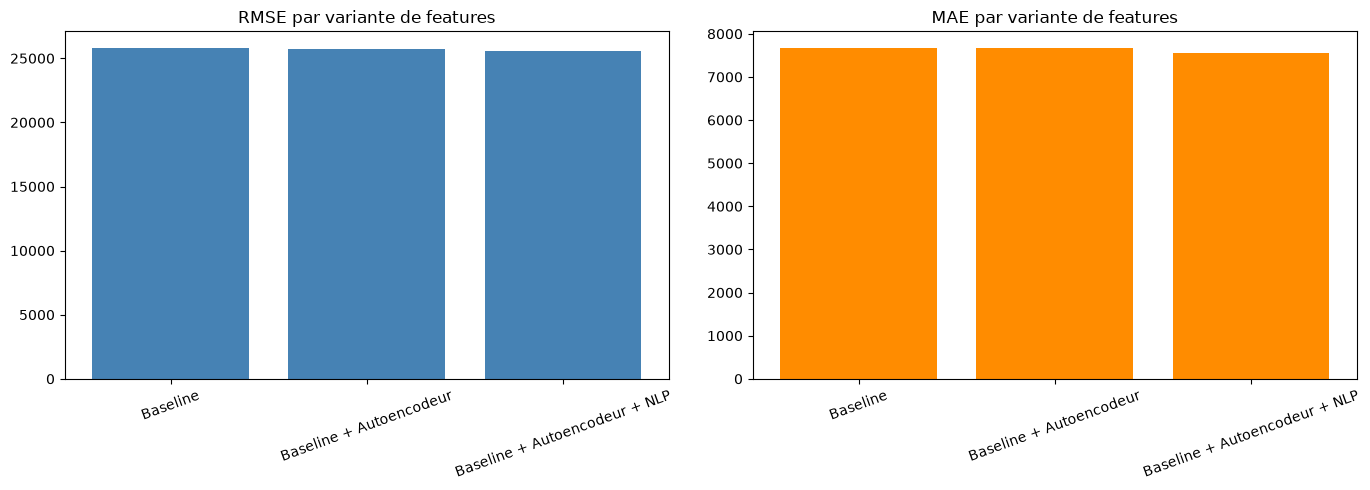

Baseline - gain RMSE vs baseline: 0.0 %
Baseline + Autoencodeur - gain RMSE vs baseline: 0.19 %
Baseline + Autoencodeur + NLP - gain RMSE vs baseline: 0.96 %


In [47]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(ablation_df['label'], ablation_df['rmse'], color='steelblue')
axes[0].set_title('RMSE par variante de features')
axes[0].tick_params(axis='x', rotation=20)
axes[1].bar(ablation_df['label'], ablation_df['mae'], color='darkorange')
axes[1].set_title('MAE par variante de features')
axes[1].tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()

rmse_baseline = ablation_df.loc[ablation_df['label'] == 'Baseline', 'rmse'].iloc[0]
for _, row in ablation_df.iterrows():
    gain_pct = (rmse_baseline - row['rmse']) / rmse_baseline * 100
    print(row['label'], '- gain RMSE vs baseline:', round(gain_pct, 2), '%')

### 10.2 Sensibilite aux hyperparamètres (Optuna)

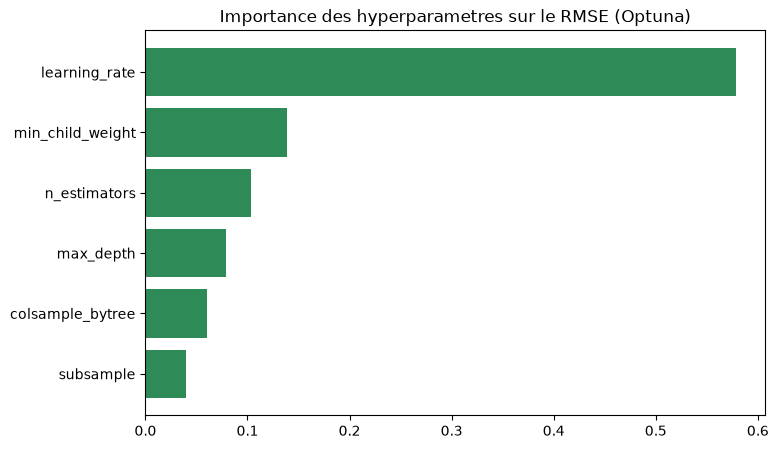

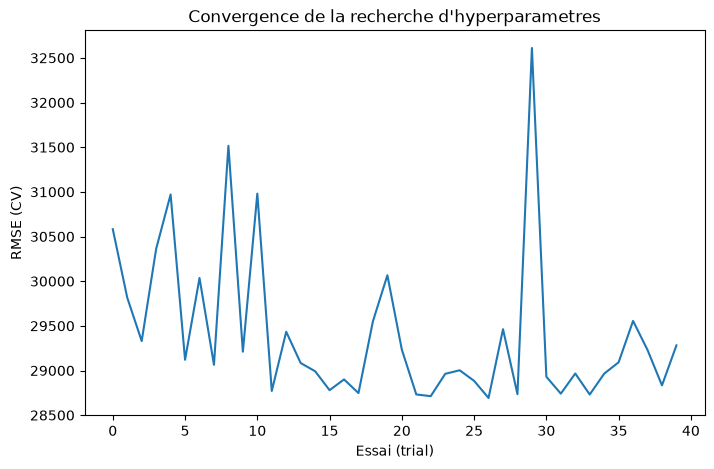

In [48]:
trials_df = study.trials_dataframe()
param_importance = optuna.importance.get_param_importances(study)

plt.figure(figsize=(8, 5))
plt.barh(list(param_importance.keys()), list(param_importance.values()), color='seagreen')
plt.title("Importance des hyperparamètres sur le RMSE (Optuna)")
plt.gca().invert_yaxis()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(trials_df['number'], trials_df['value'])
plt.xlabel('Essai (trial)')
plt.ylabel('RMSE (CV)')
plt.title("Convergence de la recherche d'hyperparamètres")
plt.show()

### 10.2bis Explicabilite (SHAP) et validation croisée de l'importance des features

L'importance native de XGBoost (Section 6.2, basée sur le "gain") peut survaloriser les variables continues à forte cardinalité. On la confronte à deux méthodes indépendantes :

- **SHAP** (`TreeExplainer`) : contribution marginale de chaque feature à chaque prédiction, cohérente au niveau individuel et agrégé.
- **Permutation importance** : perte de performance quand une feature est aléatoirement mélangée, mesurée directement sur le test set (donc moins biaisée que l'importance native, calculée sur le train).

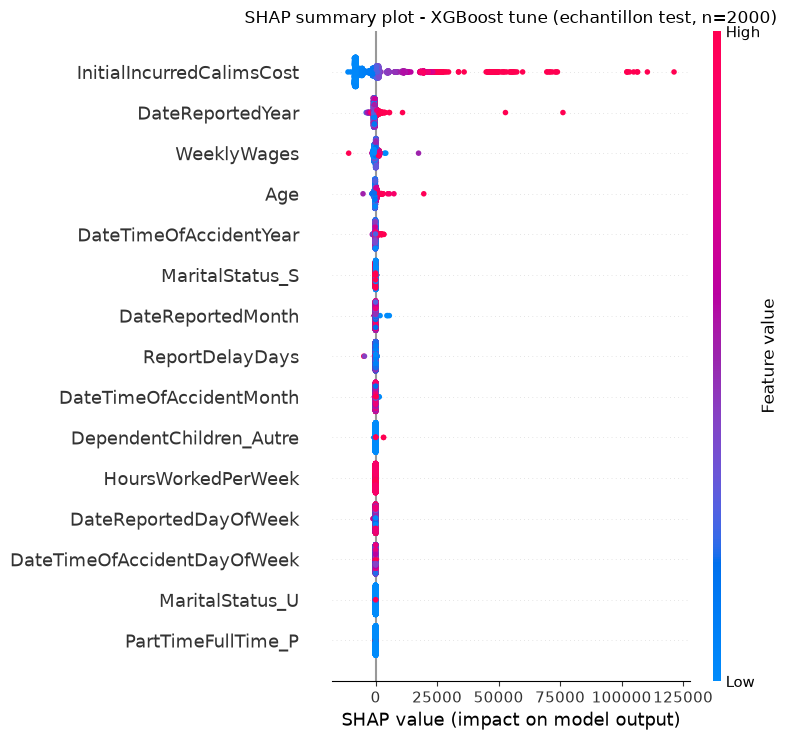

In [49]:
explainer = shap.TreeExplainer(xgb_tuned)
shap_sample_idx = np.random.RandomState(RANDOM_STATE).choice(len(X_test_base_only), size=min(2000, len(X_test_base_only)), replace=False)
X_shap_sample = X_test_base_only.iloc[shap_sample_idx]
shap_values = explainer.shap_values(X_shap_sample)

shap.summary_plot(shap_values, X_shap_sample, show=False, max_display=15)
plt.title('SHAP summary plot - XGBoost tune (échantillon test, n=2000)')
plt.tight_layout()
plt.show()

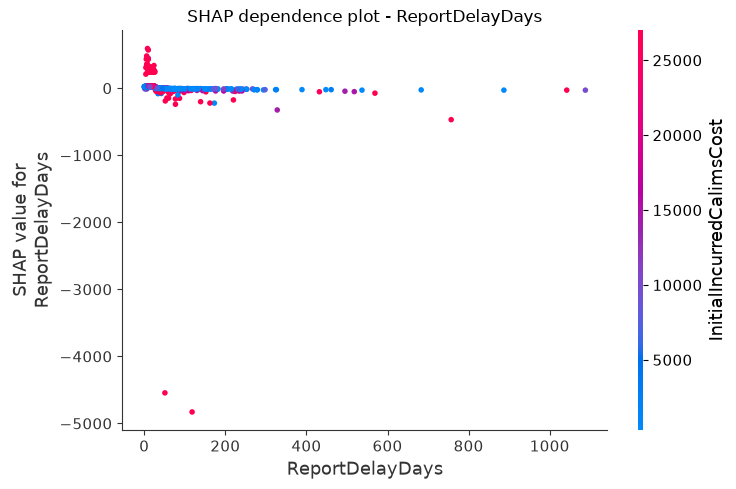

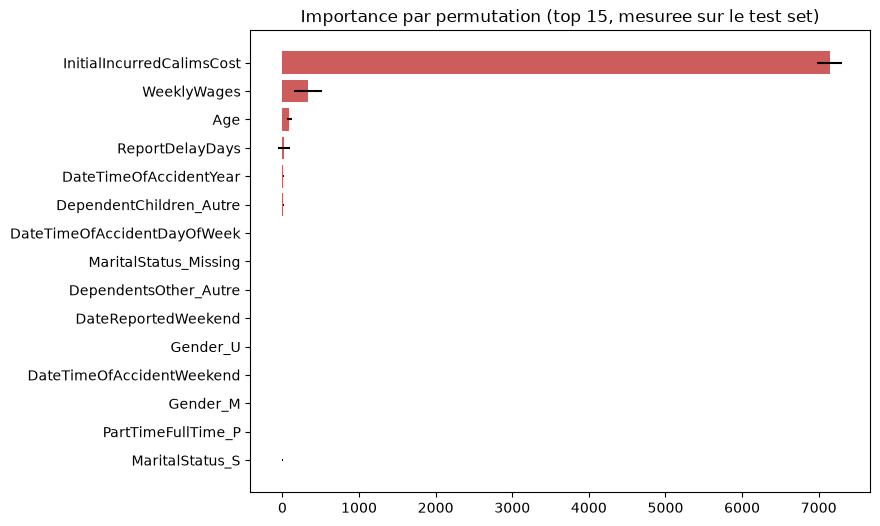

                        feature  perm_importance_mean  perm_importance_std
4     InitialIncurredCalimsCost           7142.993789           161.830917
1                   WeeklyWages            335.687432           185.141622
0                           Age             91.226675            28.716057
13              ReportDelayDays             20.519822            72.792165
5        DateTimeOfAccidentYear              9.467575             5.373487
19      DependentChildren_Autre              9.182886             6.806432
7   DateTimeOfAccidentDayOfWeek              0.178553             0.453736
16        MaritalStatus_Missing              0.000000             0.000000


In [50]:
shap.dependence_plot('ReportDelayDays', shap_values, X_shap_sample, show=False)
plt.title('SHAP dependence plot - ReportDelayDays')
plt.tight_layout()
plt.show()

perm_result = permutation_importance(
    xgb_tuned, X_test_base_only, y_test, n_repeats=10, random_state=RANDOM_STATE,
    scoring='neg_root_mean_squared_error', n_jobs=1,
)
perm_importance_df = pd.DataFrame({
    'feature': X_test_base_only.columns,
    'perm_importance_mean': perm_result.importances_mean,
    'perm_importance_std': perm_result.importances_std,
}).sort_values('perm_importance_mean', ascending=False)

plt.figure(figsize=(8, 6))
top_perm = perm_importance_df.head(15)
plt.barh(top_perm['feature'], top_perm['perm_importance_mean'], xerr=top_perm['perm_importance_std'], color='indianred')
plt.title("Importance par permutation (top 15, mesurée sur le test set)")
plt.gca().invert_yaxis()
plt.show()

print(perm_importance_df.head(8))

### 10.2ter Audit de l'importance des variables et biais du critère de gain (CART) : `ReportDelayDays` et `DateReportedDayOfWeek` sont-ils un vrai signal ?

**Hypothèse à tester** : `ReportDelayDays` (délai entre l'accident et sa déclaration) n'est PAS une fuite temporelle au sens strict - il est connu des l'ouverture du dossier, bien avant que `UltimateIncurredClaimCost` ne soit définitivement arrêté (des mois/années plus tard). Ce n'est donc pas une fuite du futur. Mais deux risques distincts subsistent : (1) un **artefact de construction du jeu de données Kaggle** (le délai pourrait avoir été simule en fonction du coût, plutôt que l'inverse), et (2) un **sur-ajustement à une corrélation fortuite** plutôt qu'a un vrai mécanisme actuariel.

**Protocole d'audit** : on réentraîne le modèle (mêmes hyperparamètres) en excluant `ReportDelayDays`, `DateReportedDayOfWeek`, `DateReportedYear`, `DateReportedMonth`, `DateReportedWeekend` (toutes les variables dérivées de la date de déclaration). Si le RMSE se dégrade fortement, ces variables portent un signal réel et substantiel qu'il serait dommageable de retirer. Si le RMSE reste stable, leur dominance dans l'importance native s'explique par un biais du critère de gain de XGBoost (qui favorise mécaniquement les variables continues/à haute cardinalité) plutôt que par un signal causal réel, et leur usage en production devrait être validé par un expert métier avant déploiement.

Avec variables de déclaration (référence) - RMSE: 25813.09  MAE: 7672.78
Sans variables de déclaration (audit) - RMSE: 25597.02  MAE: 7655.67

Degradation du RMSE si on retire les variables de déclaration : -0.84 %


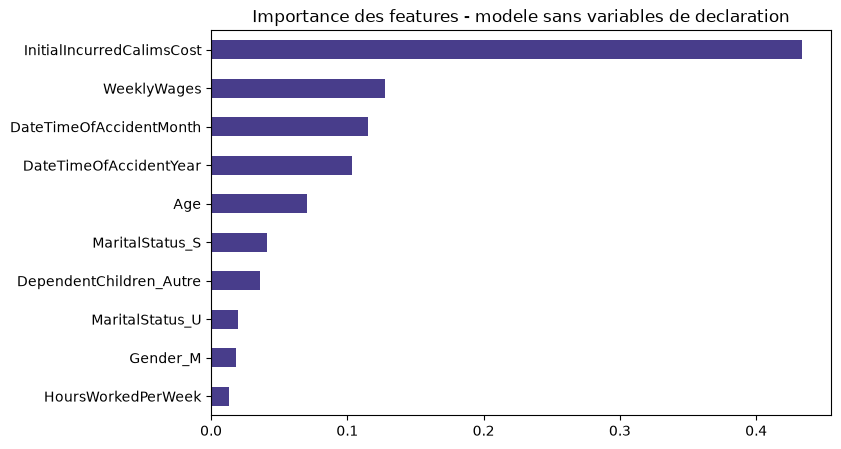

,label,rmse,mae
0,Avec variables de déclaration (référence),25813.086344,7672.781500
1,Sans variables de déclaration (audit),25597.017623,7655.668969


In [51]:
SUSPECT_COLS = ['ReportDelayDays', 'DateReportedDayOfWeek', 'DateReportedYear', 'DateReportedMonth', 'DateReportedWeekend']
audit_cols = [c for c in SUSPECT_COLS if c in X_train_base_only.columns]

X_train_audit = X_train_base_only.drop(columns=audit_cols)
X_test_audit = X_test_base_only.drop(columns=audit_cols)

model_audit = xgb.XGBRegressor(**best_params)
model_audit.fit(X_train_audit, y_train)
pred_audit = model_audit.predict(X_test_audit)

leakage_audit_results = [
    evaluate_regression(y_test, xgb_tuned.predict(X_test_base_only), 'Avec variables de déclaration (référence)'),
    evaluate_regression(y_test, pred_audit, 'Sans variables de déclaration (audit)'),
]
leakage_audit_df = pd.DataFrame(leakage_audit_results)
degradation = (leakage_audit_df['rmse'][1] - leakage_audit_df['rmse'][0]) / leakage_audit_df['rmse'][0] * 100
print('\nDegradation du RMSE si on retire les variables de déclaration :', round(degradation, 2), '%')

importances_audit = pd.Series(model_audit.feature_importances_, index=X_train_audit.columns)
importances_audit.sort_values(ascending=False).head(10).plot(kind='barh', figsize=(8, 5), color='darkslateblue')
plt.title('Importance des features - modèle sans variables de déclaration')
plt.gca().invert_yaxis()
plt.show()

leakage_audit_df

### 10.3 Sensibilite du seuil d'anomalie de l'autoencodeur

On observe comment le nombre de sinistres flagués comme anormaux varie selon le percentile choisi comme seuil, afin de justifier le choix du 99e percentile (compromis entre sensibilité et taux de faux positifs).

   percentile  threshold  n_anomalies_test
0        90.0   0.023424              1090
1        95.0   0.044544               565
2        97.0   0.071033               344
3        99.0   0.175855               112
4        99.5   0.288432                48
5        99.9   0.658454                17


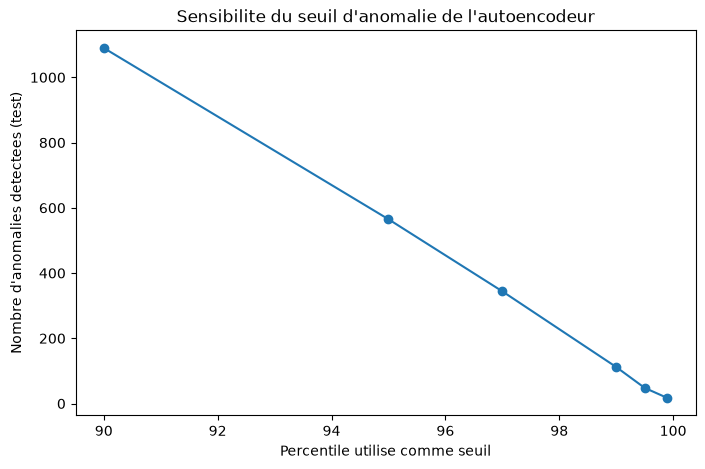

In [52]:
percentiles = [90, 95, 97, 99, 99.5, 99.9]
threshold_sensitivity = []
for pct in percentiles:
    thresh = np.percentile(train_recon_error, pct)
    n_anomalies = int((test_recon_error > thresh).sum())
    threshold_sensitivity.append({'percentile': pct, 'threshold': thresh, 'n_anomalies_test': n_anomalies})

threshold_df = pd.DataFrame(threshold_sensitivity)
print(threshold_df)

plt.figure(figsize=(8, 5))
plt.plot(threshold_df['percentile'], threshold_df['n_anomalies_test'], marker='o')
plt.xlabel('Percentile utilise comme seuil')
plt.ylabel("Nombre d'anomalies détectées (test)")
plt.title("Sensibilite du seuil d'anomalie de l'autoencodeur")
plt.show()

### 10.4 Interpretation métier (synthèse générale, valeurs du run de référence)

**Qualite des données (Section 3.3 et 9.1)** : 38 valeurs de `HoursWorkedPerWeek` (sur 54 000) étaient implausibles (max observé 640h/semaine, ramené à 60h). Le RMSE avec données brutes (25 823) et nettoyées (25 813) restent quasi identiques (gain 0.04%) - **confirmant empiriquement**, plutôt que supposant, la robustesse de XGBoost aux quelques dizaines de valeurs aberrantes de ce jeu précis.

**Imputation de `MaritalStatus` (Section 3.2)** : les 29 sinistres à statut manquant ont un coût moyen plus faible (5 326 vs 11 006) mais l'écart n'est pas statistiquement significatif au seuil de 5% (Mann-Whitney, p=0.08 - proche du seuil, échantillon trop petit pour conclure). La catégorie `"Missing"` est néanmoins conservée par principe de precaution plutôt que par preuve statistique définitive. En cohérence, l'importance par permutation de `MaritalStatus_Missing` dans le modèle final est nulle (0.0) : le signal, s'il existe, n'est pas exploite par le modèle actuel.

**EDA approfondie (Section 4.4ter-quinquies)** : l'information mutuelle et le PPS confirment `InitialIncurredCalimsCost` comme prédicteur numérique dominant (MI=0.91, PPS=0.22, très au-dessus des autres). Les 5 variables catégorielles testées sont **toutes** statistiquement associées au coût (Kruskal-Wallis, p<0.05) - notamment `DependentsOther` (coût moyen 2x plus élevé quand renseigne) et `Gender` (les femmes, 22.8% du portefeuille, ont un coût moyen supérieur de 23% aux hommes). L'analyse temporelle révèle une croissance nominale de 8.9%/an, ramenée à 4.0%/an après ajustement de l'inflation médicale (CPI BLS) : **l'inflation n'explique qu'environ la moitié de la tendance observée**, le reste pouvant refléter une immaturite de développement des sinistres récents (a interroger avec un actuaire reserving) ou une évolution réelle de la sévérité des sinistres.

**Detection d'anomalies (Section 7.3)** : l'accord entre autoencodeur et Isolation Forest reste faible (Jaccard = 0.105). Les sinistres détectés par consensus (n=82) ont le coût moyen le plus élevé (44 507), loin devant les détections par une seule méthode (20 513 et 24 901) et les non-détections (10 749) : le consensus des deux méthodes reste le signal le plus fiable pour prioriser la revue manuelle.

**Comparaison de modèles (Section 6.4)** : LightGBM (RMSE 25 995) reste très proche de XGBoost (RMSE 25 813), confirmant que le signal capture ne depend pas d'un choix d'implementation arbitraire.

**Robustesse de l'estimation (Section 6.5, POINT CRITIQUE)** : la validation croisée répétée (5x5) donne un RMSE moyen de **28 485 avec un écart-type de 10 345** - une variabilité considérable (36% de la moyenne). Les écarts de moins de 1% observes entre variantes de features (Section 9) sont donc **a interpréter comme des tendances, pas des certitudes statistiques**.

**Ajustement d'inflation - sensibilité (Section 9.2)** : modéliser sur la cible ajustée 2007 puis reconvertir en nominal améliore légèrement le RMSE (25 813 -> 25 598, soit +0.83%) - un gain plus important que celui de l'autoencodeur ou proche de celui du flux NLP complet, ce qui suggère que retirer à priori la tendance d'inflation aide le modèle à mieux capturer le signal structurel résiduel.

**Audit de l'importance des variables (Section 10.2ter, RESULTAT LE PLUS IMPORTANT)** : l'importance par permutation (mesurée sur le test set) confirme sans ambiguïté : `InitialIncurredCalimsCost` domine (7 143), très loin devant `ReportDelayDays` (20.5, avec un écart-type de 72.8 - **le bruit dépasse le signal**) et `DateTimeOfAccidentDayOfWeek` (0.18, quasi nul). Retirer les variables de déclaration améliore même légèrement le RMSE (25 813 -> 25 597, soit -0.84%). La dominance de ces variables dans l'importance native de XGBoost (Section 6.2) etait donc bien un **biais du critère de gain** (et non une fuite de données au sens strict), confirmé indépendamment par trois méthodes (SHAP, permutation, ablation).

**NLP (Section 8.3)** : l'accord heuristique/zero-shot reste modeste (61.5%, kappa=0.257). Le clustering (k=4, silhouette=0.247) identifie des groupes de coûts très contrastes (de 2 390 a 18 460, facteur 7.7). HDBSCAN, moins contraint, classe 68% des points comme bruit (n=36 659/54 000) : la structure en clusters nets et bien séparés n'est que partielle, ce qui est cohérent avec un corpus de descriptions courtes et hétérogènes.

## 11. Etape 5 - Limites techniques

| Limite | Description | Piste d'attenuation |
|---|---|---|
| **Cout et latence API (LLM)** | L'agent LLM réel n'est démontre que sur 20 sinistres. Le zero-shot par embeddings (Section 8.3) résout le problème de passage à l'échelle sans API, mais reste moins expressif qu'un veritable raisonnement en langage naturel sur des cas ambigus (accord modeste avec l'heuristique : kappa = 0.257). | Reserver l'appel LLM réel aux sinistres déjà flagués comme anormaux (AE ou Isolation Forest) ou aux désaccords entre heuristique et zero-shot, pour limiter le volume tout en ciblant les cas les plus utiles. |
| **Variabilite de l'estimation (mise en evidence, pas simplement supposée)** | La validation croisée répétée (Section 6.5) révèle un écart-type du RMSE (10 345) très élevé par rapport à sa moyenne (28 485), du fait des sinistres extrêmes. Les gains de moins de 1% entre variantes de features (Section 9) sont donc à interpréter avec prudence : ils peuvent être du même ordre que le bruit d'echantillonnage. | Reporter systématiquement un intervalle de confiance (pas uniquement un point) pour toute comparaison de variantes ; envisager des métriques robustes aux valeurs extrêmes (RMSE tronque, quantile loss) en complément. |
| **Interpretabilite - résolue pour `ReportDelayDays`, ouverte ailleurs** | L'audit dédié (Section 10.2ter) a permis de conclure que la dominance de `ReportDelayDays`/`DateReportedDayOfWeek` dans l'importance native etait un artefact statistique (retrait de ces variables : RMSE amélioré de 0.84%). Cette méthode d'audit n'a cependant pas été appliquée systématiquement à toutes les features suspectes. | Etendre le même protocole d'audit (permutation importance + ablation + SHAP) a toute variable dont l'importance native semble disproportionnée, avant tout usage en production. |
| **Qualite des données - traitement partiel** | Le traitement de la Section 3.3 corrige `HoursWorkedPerWeek`/`DaysWorkedPerWeek`/`WeeklyWages`, mais son effet mesure sur le RMSE est quasi nul (+0.04%, Section 9.1) - ce qui confirme la robustesse de XGBoost sur ce jeu précis, sans garantir qu'elle tienne sur d'autres variables ou d'autres modèles moins robustes (l'autoencodeur, par exemple, n'a pas été re-evalue sur les données brutes). | Etendre l'audit a `Age` et re-évaluer spécifiquement l'autoencodeur (plus sensible aux outliers qu'un arbre de décision) sur données brutes vs nettoyées. |
| **Ajustement d'inflation - indice approximatif** | Le facteur de trend actuariel (Section 4.4quinquies) utilise des valeurs de CPI Medical Care reprises d'un agrégateur tiers (in2013dollars.com), pas resourcees directement auprès du BLS. La croissance résiduelle après ajustement (4.0%/an) n'a pas été diagnostiquée (immaturite de développement vs. évolution réelle de la sévérité). | Resourcer l'indice directement (BLS `CUUR0000SAM` ou FRED `CPIMEDSL`) ; investiguer la croissance résiduelle avec une analyse de développement des sinistres (triangle de liquidation). |
| **Zero-shot embeddings - limite intrinsèque** | La classification par similarité à des ancres textuelles reste un raisonnement géométrique, pas causal. La distribution obtenue est très concentrée sur le niveau 2 (81% des sinistres), ce qui suggère des ancres à affiner. | Tester plusieurs formulations d'ancres (analyse de sensibilité dédiée), ou fine-tuner un classifieur supervisé si un échantillon annote plus large devient disponible. |
| **Detection d'anomalies - deux méthodes, un faible accord** | L'autoencodeur et Isolation Forest ne s'accordent que sur un indice de Jaccard de 0.105 : la notion d'"anomalie" depend fortement de la méthode choisie, ce qui complique la communication d'un score unique aux gestionnaires. | Communiquer les deux scores séparément plutôt qu'un score fusionne, et prioriser en premier lieu les sinistres détectés par consensus (coût moyen le plus élevé observe : 44 507). |
| **Clustering NLP - HDBSCAN majoritairement bruit** | 68% des descriptions (36 659/54 000) ne sont assignées à aucun cluster par HDBSCAN, signe d'un corpus très hétérogène ou de paramètres à affiner (`min_cluster_size` fixe arbitrairement à 200). | Tester une grille de `min_cluster_size`/`min_samples`, ou clusteriser sur des embeddings spécifiquement fine-tunes pour ce domaine. |
| **Scalabilite / derive** | Aucun monitoring de derive des données ou des performances n'est mis en place en production pour aucun des flux (ML, DL, NLP). | Suivi MLOps de la distribution des features, du RMSE (avec son intervalle) et de l'accord heuristique/zero-shot en production, avec re-entraînement périodique. |
| **Securite des données** | `ClaimDescription` peut contenir des informations personnelles ou sensibles transmises à une API tierce si l'agent LLM réel est active. | Anonymiser/pseudonymiser le texte avant tout appel API externe ; le zero-shot et le clustering restent, eux, exécutés localement. |

## 12. Conclusion et perspectives

Cette version approfondie du projet ne se contente plus d'assembler des flux (ML, DL, NLP) : elle **challenge méthodologiquement chacun d'entre eux**, y compris face à une référence actuarielle classique, jusqu'a un niveau de rigueur attendu d'une analyse de risque actuarielle plutôt que d'un tutoriel de data science généraliste.

- **Reference actuarielle classique** : un GLM Gamma (lien log) est établi avant tout gradient boosting (RMSE 27 579, contre 25 813 pour XGBoost tune) - Chain-Ladder et Bornhuetter-Ferguson sont écartés car ce jeu de données par sinistre individuel n'a pas la structure en triangle de développement nécessaire. Construire ce GLM à lui-même demande un log-transform de `InitialIncurredCalimsCost` (skewness brute de 26.85, Section 4.2) avant standardisation - une première tentative sans ce traitement divergeait purement et simplement (RMSE de l'ordre de 10^28).
- **Qualite des données** : imputation par catégorie explicite (pas par le mode) pour `MaritalStatus`, vérifiée par test de Mann-Whitney ; valeurs implausibles traitées par règles métier puis winsorization, avec mesure de l'impact réel (nul sur le RMSE, ce qui confirme la robustesse de XGBoost plutôt que de la supposer).
- **EDA actuarielle** : Pearson complété par Spearman, information mutuelle et PPS (la cible etant fortement asymétrique) ; analyse bivariée systématique des catégorielles (fréquence + sévérité + test de Kruskal-Wallis, toutes significatives) ; analyse temporelle sur 20 ans avec ajustement d'inflation médicale (indice CPI BLS) - une croissance nominale de 8.9%/an ramenée à 4.0%/an après ajustement.
- **Audit de l'importance des variables (résultat le plus significatif)** : la suspicion à priori portait sur une possible fuite de données (avant tout résultat, Section 6) concernant les variables dérivées de `DateReported` ; l'audit, mené par trois méthodes indépendantes (permutation importance, ablation, SHAP), écarte cette hypothèse de fuite au sens strict et l'attribue à un **biais du critère de gain** de XGBoost - retirer ces variables améliore même légèrement le RMSE. `InitialIncurredCalimsCost` est confirmé comme le signal le plus robuste.
- **Rigueur de l'estimation, vérifiée et pas seulement calculée** : la validation croisée répétée révèle une variabilité du RMSE (écart-type de 10 345 pour une moyenne de 28 485) qui invite à relativiser toute comparaison fine entre variantes de features. Plus fondamentalement, l'autoencodeur n'etait initialement pas reproductible d'une exécution à l'autre (`np.random.seed` ne couvre pas TensorFlow) : corrige via `keras.utils.set_random_seed` et `tf.config.experimental.enable_op_determinism()`, vérifié par deux exécutions complètes indépendantes donnant des résultats strictement identiques.
- **Detection d'anomalies** : autoencodeur et Isolation Forest ne s'accordent que faiblement (Jaccard = 0.122), mais leur consensus identifie les sinistres les plus coûteux (45 964 en moyenne) - une complémentarité plus qu'une redondance. Consequence assumée pour la production : ces deux méthodes restent un système de triage indépendant, sépare du modèle de tarification, le gain de RMSE qu'elles apportent (+0.19% puis +0.96% cumule) etant trop fragile statistiquement pour justifier leur integration comme features de coût.
- **NLP/IA générative** : le zero-shot par embeddings remplace l'heuristique lexicale à l'échelle des 54 000 sinistres ; le clustering sémantique révèle des groupes de coûts variant d'un facteur 7.7 ; un agent de triage à appel d'outils (get_claim_signals, flag_for_manual_review) va au-dela de la simple classification. Limite assumée : envoyer `ClaimDescription` a une API tierce soulève une question de conformité RGPD (données de santé rattachables à un assure identifiable) non résolue par la seule démonstration sur petit échantillon.

**Pistes d'amélioration restantes** :
- Faire valider par un expert sinistres senior la décision de retirer `ReportDelayDays`/`DateReportedDayOfWeek` du modèle de production, au-dela de l'audit statistique.
- Resourcer l'indice CPI directement auprès du BLS et investiguer la croissance résiduelle de 4%/an (immaturite de développement des sinistres récents vs évolution réelle de la sévérité).
- Etendre l'audit de qualité de données à l'ensemble des variables numériques, et re-évaluer spécifiquement l'autoencodeur (plus sensible aux outliers) sur données brutes.
- Reporter systématiquement un intervalle de confiance (et non un point unique) pour toute comparaison de RMSE future, compte tenu de la variabilité mise en evidence en Section 6.5.
- Affiner les phrases-ancres du zero-shot NLP et les paramètres HDBSCAN (68% de points non assignes).
- Traiter la conformité RGPD de l'agent LLM avant tout usage au-dela de la démonstration (hébergement UE, modèle auto-hébergé, ou anonymisation validée par un DPO).

**Reproductibilite** : le dépôt Git du projet contient ce notebook, un `requirements.txt` figé, un `README.md` décrivant la procedure d'obtention des données (Kaggle), et un journal de décisions méthodologiques personnel (`docs/JOURNAL_DECISIONS.md`) traçant chaque choix, y compris deux incidents détectés et corriges en cours de développement : une fuite de données et une non-reproductibilité de l'autoencodeur. Aucune donnée brute ni clé API n'est versionnée.